In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import MinMaxScaler

In [2]:
CEFEC =pd.read_csv('data_selec_entre.csv',encoding="ISO-8859-1",sep=',')
CEFEC.head()

,NUMPRIORIZACION,NC_DISTR12,TOTGEST6,TOTGEST12,IDGRUPO,DIAS_ACT,FBK_ULT6,FBK_ULT12,FBK_BEST6,DIAS_BEST6,...,NT_CTD6,NT_DISTR6,NT_DIAS6,PROVINCIA,DEPARTAMENTO,INGRESO_NETO_VIGENTE,INGRESO_BRUTO,SEGMENTO,RANGO_INGRESOS,TARGET
0,1,0.333333,6,6,3,118,TLV,TLV,TLV,8,...,-999,-999.0,-999,TACNA,TACNA,7136,9389,2,Entre S/.4000-10000,1
1,1,0.461538,13,13,40,94,TLV,TLV,TLV,46,...,-999,-999.0,-999,LIMA,LIMA,6920,9105,1BC,Entre S/.4000-10000,1
2,1,0.666667,2,6,6,223,TLV,TLV,TLV,127,...,-999,-999.0,-999,LIMA,LIMA,1473,1655,2,Entre S/.1000-4000,1
3,1,-999.000000,4,4,95,96,TLV,TLV,TLV,49,...,-999,-999.0,-999,LIMA,LIMA,2293,2729,2,Entre S/.1000-4000,1
4,1,0.187500,10,16,4,91,TLV,TLV,TLV,27,...,-999,-999.0,-999,CUSCO,CUSCO,6470,8513,3,Entre S/.4000-10000,1


Empezamos a cargar la data train 

TRATAMIENTO DE LA DATA

In [87]:
CEFEC.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 757391 entries, 0 to 757390
Data columns (total 40 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   NUMPRIORIZACION       757391 non-null  int64  
 1   NC_DISTR12            757391 non-null  float64
 2   TOTGEST6              757391 non-null  int64  
 3   TOTGEST12             757391 non-null  int64  
 4   IDGRUPO               757391 non-null  int64  
 5   DIAS_ACT              757391 non-null  int64  
 6   FBK_ULT6              757391 non-null  object 
 7   FBK_ULT12             757391 non-null  object 
 8   FBK_BEST6             757391 non-null  object 
 9   DIAS_BEST6            757391 non-null  int64  
 10  DIAS_ULT6             757391 non-null  int64  
 11  FBK_BEST12            757391 non-null  object 
 12  DIAS_BEST12           757391 non-null  int64  
 13  DIAS_ULT12            757391 non-null  int64  
 14  CNE_CTD12             757391 non-null  int64  
 15  

In [3]:
CEFEC = CEFEC.replace(-999, np.nan)

Reemplazamos los valores '-999' por los valores nulos correspondientes de Python

In [75]:
CEFEC.isnull().sum()[CEFEC.isnull().sum() > 0]

NC_DISTR12              249939
TOTGEST6                191950
TOTGEST12               169506
DIAS_BEST6              191950
DIAS_ULT6               191950
DIAS_BEST12             169506
DIAS_ULT12              169506
CNE_CTD12               455346
CNE_CTD6                496789
CNE_DIAS6               496789
CNE_DISTR6              496789
CNE_DISTR12             455346
CNE_DIAS12              455346
NC_CTD12                249939
NC_DIAS6                283215
NC_DIAS12               249939
NC_CTD6                 283215
RECENCIA_APP            681465
NT_CTD12                706221
NT_DISTR12              706221
NT_DIAS12               706221
NT_CTD6                 722212
NT_DISTR6               722212
NT_DIAS6                722212
INGRESO_NETO_VIGENTE      1360
INGRESO_BRUTO             1360
dtype: int64

Identificamos las variables que tienen datos nulos

In [4]:
vars_gestion = [
   'NC_DISTR12', 'TOTGEST6', 'TOTGEST12', 'IDGRUPO',
       'DIAS_ACT', 'DIAS_BEST6','DIAS_ULT6', 'DIAS_BEST12', 'DIAS_ULT12', 'CNE_CTD12',
       'CNE_CTD6', 'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12', 'CNE_DIAS12',
       'NC_CTD12', 'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6', 'RECENCIA_APP',
       'INGRESO_NETO_VIGENTE', 'INGRESO_BRUTO'
]

resumen_gestion = []

for col in vars_gestion:
    if col in CEFEC.columns:
        # Cálculo de Cuartiles
        Q1 = CEFEC[col].quantile(0.25)
        Q3 = CEFEC[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Límites con "Piso en Cero"
        limite_inf = max(0, Q1 - 1.5 * IQR)
        limite_sup = Q3 + 1.5 * IQR
        
        # Conteo de sospechosos
        negativos = CEFEC[CEFEC[col] < 0].shape[0]
        excesos = CEFEC[CEFEC[col] > limite_sup].shape[0]
        
        total_a_eliminar = negativos + excesos
        porcentaje = (total_a_eliminar / len(CEFEC)) * 100
        
        resumen_gestion.append({
            'Variable': col,
            'Rango Lógico': f"[{limite_inf:.1f} a {limite_sup:.1f}]",
            '% de Pérdida': f"{porcentaje:.2f}%"
        })

# 2. Imprimir la tabla de auditoría
df_auditoria_gest = pd.DataFrame(resumen_gestion)
print("--- AUDITORÍA DE GESTIÓN Y CONTACTABILIDAD ---")
print(df_auditoria_gest)

# 3. Impacto si decides borrar estas variables también
mascara_gest = pd.Series([False] * len(CEFEC))
for col in vars_gestion:
    if col in CEFEC.columns:
        Q1 = CEFEC[col].quantile(0.25)
        Q3 = CEFEC[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_sup = Q3 + 1.5 * IQR
        mascara_gest |= (CEFEC[col] < 0) | (CEFEC[col] > limite_sup)

print(f"\n📢 IMPACTO ADICIONAL: Se eliminarían {mascara_gest.sum()} filas únicas por estas variables.")

--- AUDITORÍA DE GESTIÓN Y CONTACTABILIDAD ---
                Variable     Rango Lógico % de Pérdida
0             NC_DISTR12      [0.0 a 1.4]        0.00%
1               TOTGEST6     [0.0 a 23.0]        2.12%
2              TOTGEST12     [0.0 a 30.5]        2.25%
3                IDGRUPO    [0.0 a 139.0]        0.00%
4               DIAS_ACT    [0.0 a 673.0]       12.03%
5             DIAS_BEST6    [0.0 a 180.0]        3.10%
6              DIAS_ULT6    [0.0 a 118.0]        5.84%
7            DIAS_BEST12    [0.0 a 218.5]        5.01%
8             DIAS_ULT12    [0.0 a 129.0]        7.82%
9              CNE_CTD12      [0.0 a 6.0]        2.66%
10              CNE_CTD6      [0.0 a 6.0]        1.46%
11             CNE_DIAS6    [0.0 a 266.0]        0.00%
12            CNE_DISTR6      [0.0 a 0.6]        1.89%
13           CNE_DISTR12      [0.0 a 0.7]        1.80%
14            CNE_DIAS12    [0.0 a 349.0]        0.44%
15              NC_CTD12     [0.0 a 14.5]        3.27%
16              NC

Vemos el porcentaje de valores atípicos que hay en la base de datos

Con lo visto, procederemos a eliminar e imputar las variables correspondientes

In [5]:
vars_a_eliminar = [
    'NT_DISTR6', 
    'NT_DISTR12', 
    'NT_DIAS6', 
    'NT_DIAS12', 
    'NT_CTD6', 
    'NT_CTD12',
    'RECENCIA_APP'
]

CEFEC.drop(columns=vars_a_eliminar, inplace=True)

Se eliminan estas variables ya que tienen entre 90% a 96% de datos nulos, lo que las hace poco útiles para el análisis y modelado. Además, su eliminación no afectará significativamente la calidad de los datos restantes. 

In [78]:
CEFEC.columns

Index(['NUMPRIORIZACION', 'NC_DISTR12', 'TOTGEST6', 'TOTGEST12', 'IDGRUPO',
       'DIAS_ACT', 'FBK_ULT6', 'FBK_ULT12', 'FBK_BEST6', 'DIAS_BEST6',
       'DIAS_ULT6', 'FBK_BEST12', 'DIAS_BEST12', 'DIAS_ULT12', 'CNE_CTD12',
       'CNE_CTD6', 'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12', 'CNE_DIAS12',
       'NC_CTD12', 'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6', 'COD_SALA',
       'FEC_LLAMADA', 'PROVINCIA', 'DEPARTAMENTO', 'INGRESO_NETO_VIGENTE',
       'INGRESO_BRUTO', 'SEGMENTO', 'RANGO_INGRESOS', 'TARGET'],
      dtype='object')

In [6]:
vars_gestion = [
   'TOTGEST6', 'TOTGEST12', 'DIAS_ACT'
]

resumen_gestion = []

for col in vars_gestion:
    if col in CEFEC.columns:
        # Cálculo de Cuartiles
        Q1 = CEFEC[col].quantile(0.25)
        Q3 = CEFEC[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Límites con "Piso en Cero"
        limite_inf = max(0, Q1 - 1.5 * IQR)
        limite_sup = Q3 + 1.5 * IQR
        
        # Conteo de sospechosos
        negativos = CEFEC[CEFEC[col] < 0].shape[0]
        excesos = CEFEC[CEFEC[col] > limite_sup].shape[0]
        
        total_a_eliminar = negativos + excesos
        porcentaje = (total_a_eliminar / len(CEFEC)) * 100
        
        resumen_gestion.append({
            'Variable': col,
            'Rango Lógico': f"[{limite_inf:.1f} a {limite_sup:.1f}]",
            '% de Pérdida': f"{porcentaje:.2f}%"
        })

# 2. Imprimir la tabla de auditoría
df_auditoria_gest = pd.DataFrame(resumen_gestion)
print("--- AUDITORÍA DE GESTIÓN Y CONTACTABILIDAD ---")
print(df_auditoria_gest)

# 3. Impacto si decides borrar estas variables también
mascara_gest = pd.Series([False] * len(CEFEC))
for col in vars_gestion:
    if col in CEFEC.columns:
        Q1 = CEFEC[col].quantile(0.25)
        Q3 = CEFEC[col].quantile(0.75)
        IQR = Q3 - Q1
        limite_sup = Q3 + 1.5 * IQR
        mascara_gest |= (CEFEC[col] < 0) | (CEFEC[col] > limite_sup)

total_antes = len(CEFEC)
# Filtramos CEFEC manteniendo solo las filas donde la máscara es False
# (Es decir, donde NO se detectaron outliers ni negativos)
CEFEC = CEFEC[~mascara_gest].copy()

total_despues = len(CEFEC)
eliminados = total_antes - total_despues

# 5. Reporte de Ejecución
print("\n" + "="*40)
print("🚀 EJECUCIÓN DE LIMPIEZA FINALIZADA")
print("="*40)
print(f"✅ Registros procesados: {total_antes}")
print(f"✅ Registros eliminados: {eliminados}")
print(f"✅ Registros restantes:  {total_despues}")
print("="*40)

--- AUDITORÍA DE GESTIÓN Y CONTACTABILIDAD ---
    Variable   Rango Lógico % de Pérdida
0   TOTGEST6   [0.0 a 23.0]        2.12%
1  TOTGEST12   [0.0 a 30.5]        2.25%
2   DIAS_ACT  [0.0 a 673.0]       12.03%

🚀 EJECUCIÓN DE LIMPIEZA FINALIZADA
✅ Registros procesados: 757391
✅ Registros eliminados: 114355
✅ Registros restantes:  643036


Eliminamos los valores atípicos de la variable con mayor cantidad que es 'DIAS_ACT' y tambien se decide eliminar las de las variables 'TOTGEST' ya que representan la cantidad de llamadas que se hacen en los clientes, y esta variable esta relacionada con más, por ejemplo 'NC_CTD', 'CNE_CTD', 'NC_DISTR', etc

In [7]:
for col in ['TOTGEST6', 'TOTGEST12']:
    CEFEC[col] = CEFEC.groupby('SEGMENTO')[col].transform(lambda x: x.fillna(x.median()))
    
    mediana_global = CEFEC[col].median()
    CEFEC[col] = CEFEC[col].fillna(mediana_global)

print("✅ Totales (6m y 12m) imputados por mediana de segmento.")


periodos = [
    {'total': 'TOTGEST6', 'nc': 'NC_CTD6', 'cne': 'CNE_CTD6'},
    {'total': 'TOTGEST12', 'nc': 'NC_CTD12', 'cne': 'CNE_CTD12'}
]

for p in periodos:
    ambos_nan = CEFEC[p['nc']].isna() & CEFEC[p['cne']].isna()
    CEFEC.loc[ambos_nan, p['nc']] = np.round(CEFEC.loc[ambos_nan, p['total']] * 0.65)
    CEFEC.loc[ambos_nan, p['cne']] = CEFEC.loc[ambos_nan, p['total']] - CEFEC.loc[ambos_nan, p['nc']]
    
    CEFEC[p['cne']] = CEFEC[p['cne']].fillna(CEFEC[p['total']] - CEFEC[p['nc']].fillna(0))
    CEFEC[p['nc']] = CEFEC[p['nc']].fillna(CEFEC[p['total']] - CEFEC[p['cne']].fillna(0))
    
    CEFEC[p['cne']] = CEFEC[p['cne']].clip(lower=0).round().astype(int)
    CEFEC[p['nc']] = CEFEC[p['nc']].clip(lower=0).round().astype(int)

print("✅ Variables NC y CNE (6m y 12m) imputadas y convertidas a entero.")

✅ Totales (6m y 12m) imputados por mediana de segmento.
✅ Variables NC y CNE (6m y 12m) imputadas y convertidas a entero.


In [8]:
dict_medianas_6 = CEFEC.groupby('SEGMENTO')['TOTGEST6'].median().to_dict()
dict_medianas_12 = CEFEC.groupby('SEGMENTO')['TOTGEST12'].median().to_dict()

global_6 = CEFEC['TOTGEST6'].median()
global_12 = CEFEC['TOTGEST12'].median()

Luego de eliminar esos datos atípicos, se procede con la imputación. Primero se pasa a imputar la variable TOTGEST, Y de acuerdo a ella, se pasa a imputar las variables NC_CTD y CNE_CTD, respetando que la suma de estas 2 tiene que ser igual a la suma de la cantidad de llamadas, no puede sobrepasar el numero de TOTGEST

C:\Users\stefa\AppData\Local\Temp\ipykernel_5416\1941615261.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='NC_DIAS12', data=CEFEC, palette='viridis')


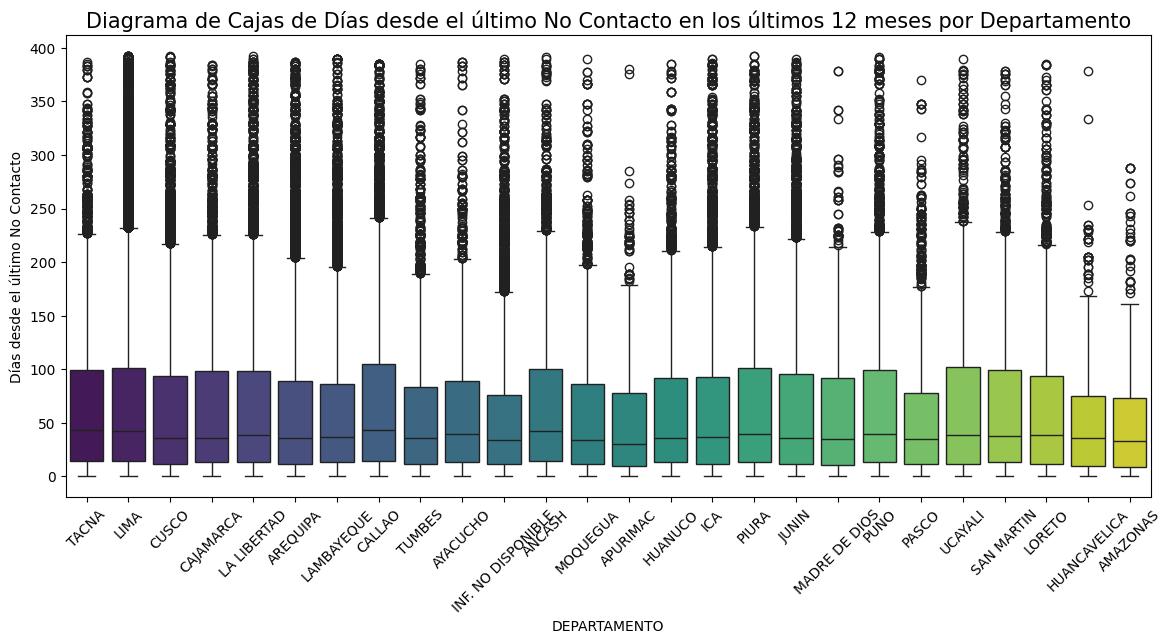

C:\Users\stefa\AppData\Local\Temp\ipykernel_5416\1941615261.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='NC_DIAS12', data=CEFEC, order=orden_seg, palette='Set2')


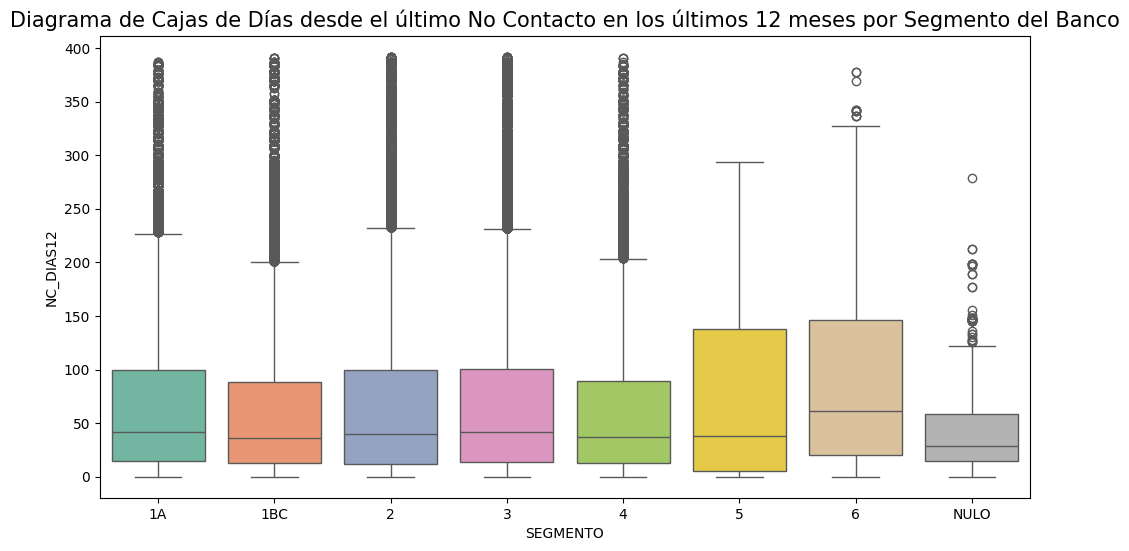

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='DEPARTAMENTO', y='NC_DIAS12', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el último No Contacto en los últimos 12 meses por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Días desde el último No Contacto')
plt.show()


plt.figure(figsize=(12, 6))
orden_seg = ['1A', '1BC', '2', '3', '4', '5', '6', 'NULO']
orden_seg = [s for s in orden_seg if s in CEFEC['SEGMENTO'].unique()]

sns.boxplot(x='SEGMENTO', y='NC_DIAS12', data=CEFEC, order=orden_seg, palette='Set2')
plt.title('Diagrama de Cajas de Días desde el último No Contacto en los últimos 12 meses por Segmento del Banco', fontsize=15)
plt.show()

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2497373177.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='NC_DIAS6', data=CEFEC, palette='viridis')


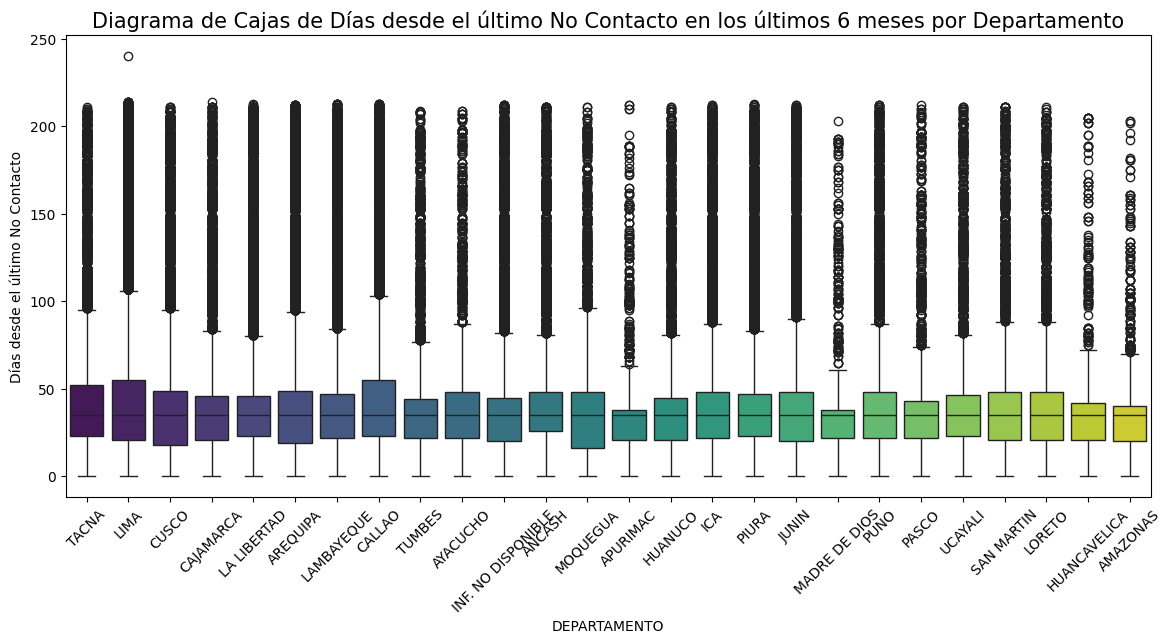

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2497373177.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='NC_DIAS6', data=CEFEC, order=orden_seg, palette='Set2')


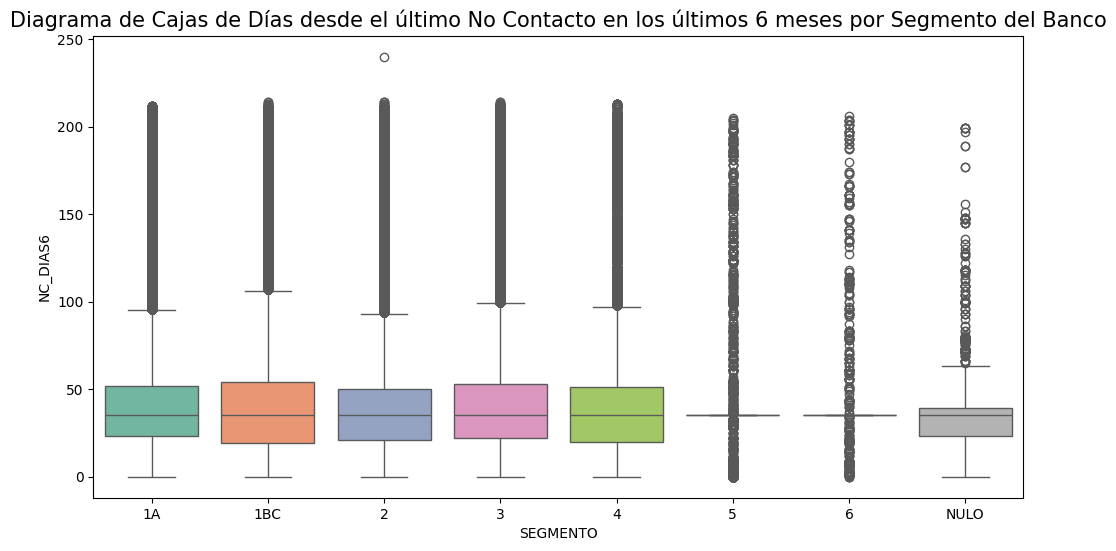

In [29]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='DEPARTAMENTO', y='NC_DIAS6', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el último No Contacto en los últimos 6 meses por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Días desde el último No Contacto')
plt.show()


plt.figure(figsize=(12, 6))
orden_seg = ['1A', '1BC', '2', '3', '4', '5', '6', 'NULO']

orden_seg = [s for s in orden_seg if s in CEFEC['SEGMENTO'].unique()]

sns.boxplot(x='SEGMENTO', y='NC_DIAS6', data=CEFEC, order=orden_seg, palette='Set2')
plt.title('Diagrama de Cajas de Días desde el último No Contacto en los últimos 6 meses por Segmento del Banco', fontsize=15)
plt.show()

In [10]:
cols_base = ['NC_DIAS12', 'NC_DIAS6']

for col in cols_base:
    mediana_val = CEFEC[col].median()
    CEFEC[col] = CEFEC[col].fillna(mediana_val)
    print(f"Mediana de {col}: {mediana_val}")

Mediana de NC_DIAS12: 40.0
Mediana de NC_DIAS6: 35.0


In [11]:
mediana_nc_dias12 = CEFEC['NC_DIAS12'].median()
mediana_nc_dias6 = CEFEC['NC_DIAS6'].median()
print(f"Mediana NC_DIAS12: {mediana_nc_dias12}")
print(f"Mediana NC_DIAS6: {mediana_nc_dias6}")  

Mediana NC_DIAS12: 40.0
Mediana NC_DIAS6: 35.0


Luego, se pasa a imputar las demas variables. Seguimos con la variable NC_DIAS, y hacemos unos graficos segmentandola por otras variables para ver si es necesario o no. Como se ve, no hay mucha diferencias por segmento, por eso se decide imputar por la mediana global

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2102409197.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='INGRESO_NETO_VIGENTE', data=df_plot, palette='Set3')


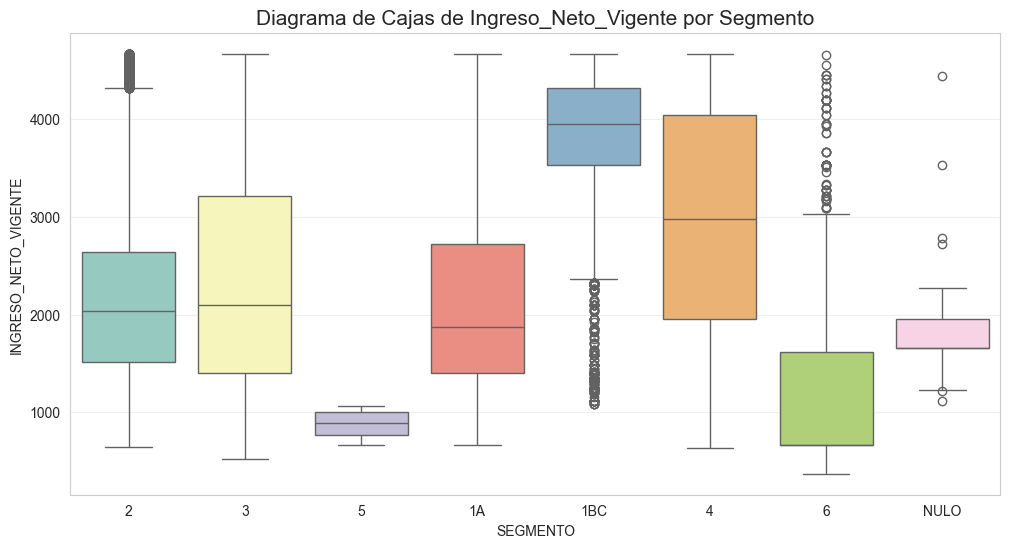

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2102409197.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='INGRESO_NETO_VIGENTE', data=df_plot, palette='viridis')


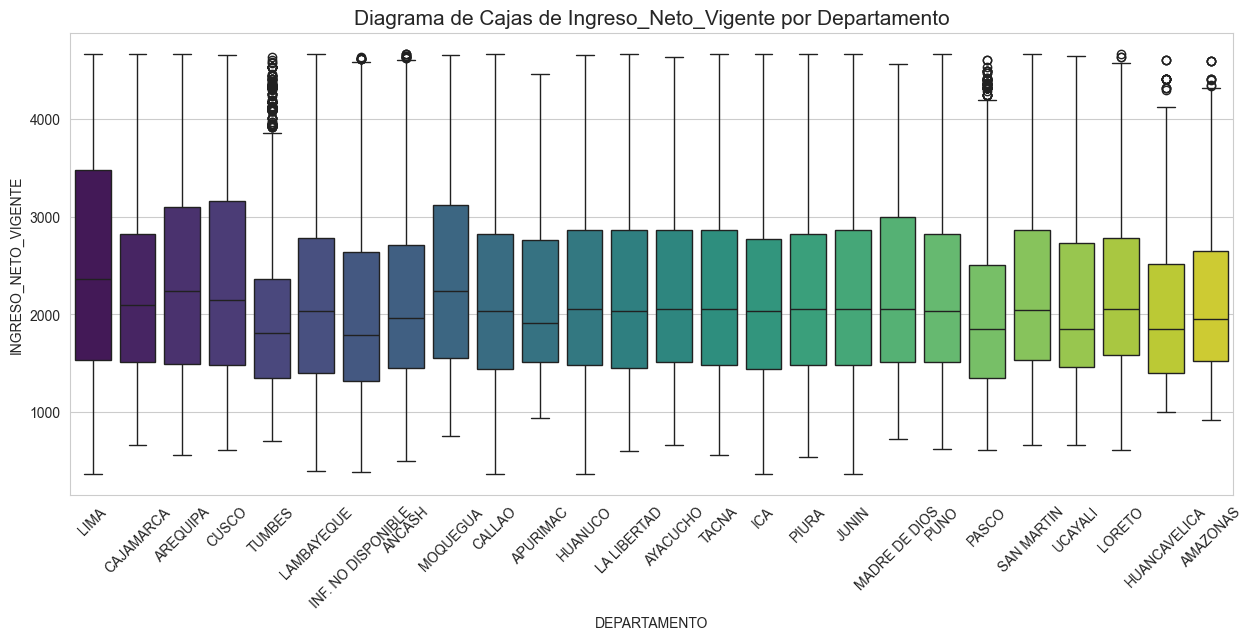

In [64]:
plt.figure(figsize=(12, 6))

df_plot = CEFEC[CEFEC['INGRESO_NETO_VIGENTE'] < CEFEC['INGRESO_NETO_VIGENTE'].quantile(0.75)] 

sns.boxplot(x='SEGMENTO', y='INGRESO_NETO_VIGENTE', data=df_plot, palette='Set3')
plt.title('Diagrama de Cajas de Ingreso_Neto_Vigente por Segmento', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(x='DEPARTAMENTO', y='INGRESO_NETO_VIGENTE', data=df_plot, palette='viridis')
plt.title('Diagrama de Cajas de Ingreso_Neto_Vigente por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.show()

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\954722029.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='INGRESO_BRUTO', data=df_plot, palette='Set3')


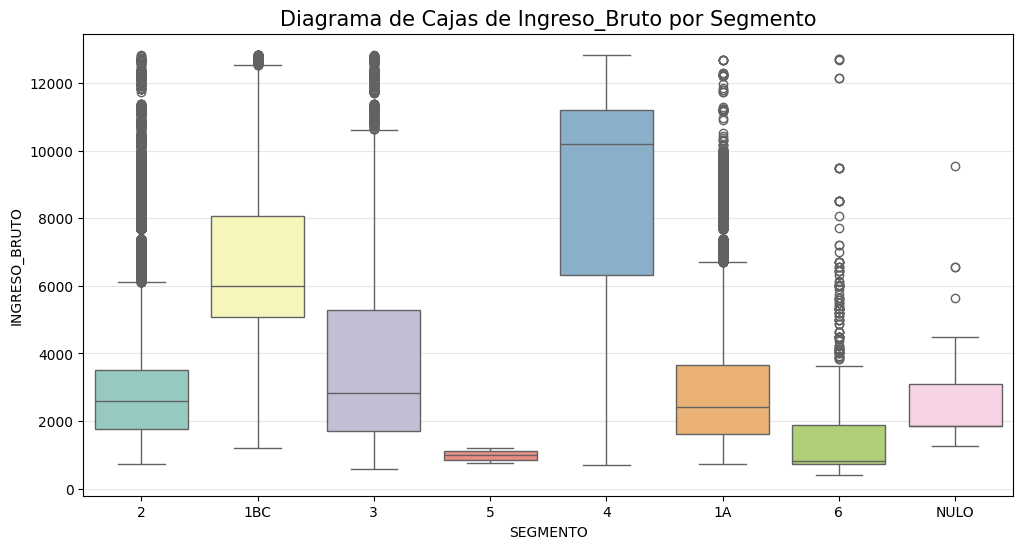

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\954722029.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='INGRESO_BRUTO', data=df_plot, palette='viridis')


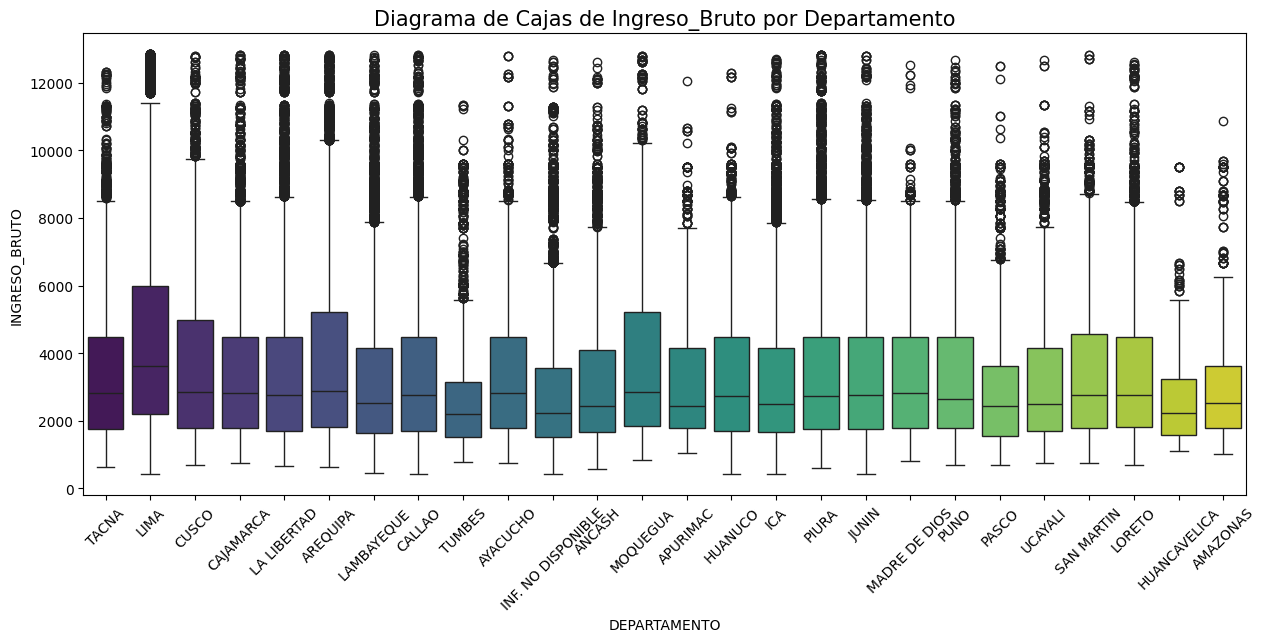

In [20]:

plt.figure(figsize=(12, 6))

df_plot = CEFEC[CEFEC['INGRESO_BRUTO'] < CEFEC['INGRESO_BRUTO'].quantile(0.95)] 

sns.boxplot(x='SEGMENTO', y='INGRESO_BRUTO', data=df_plot, palette='Set3')
plt.title('Diagrama de Cajas de Ingreso_Bruto por Segmento', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.show()


plt.figure(figsize=(15, 6))
sns.boxplot(x='DEPARTAMENTO', y='INGRESO_BRUTO', data=df_plot, palette='viridis')
plt.title('Diagrama de Cajas de Ingreso_Bruto por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.show()

In [12]:
medianas_por_segmento = CEFEC.groupby('SEGMENTO')['INGRESO_NETO_VIGENTE'].transform('median')
CEFEC['INGRESO_NETO_VIGENTE'] = CEFEC['INGRESO_NETO_VIGENTE'].fillna(medianas_por_segmento)

medianas_por_segmento2 = CEFEC.groupby('SEGMENTO')['INGRESO_BRUTO'].transform('median')
CEFEC['INGRESO_BRUTO'] = CEFEC['INGRESO_BRUTO'].fillna(medianas_por_segmento2)

In [13]:
dict_ingreso_neto = CEFEC.groupby('SEGMENTO')['INGRESO_NETO_VIGENTE'].median().to_dict()
dict_ingreso_bruto = CEFEC.groupby('SEGMENTO')['INGRESO_BRUTO'].median().to_dict()

global_neto = CEFEC['INGRESO_NETO_VIGENTE'].median()
global_bruto = CEFEC['INGRESO_BRUTO'].median()

Para la variable de Ingresos, vemos que por segmento hay diferencias, así que lo imputamos segmentandolo por esta variable.

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\1337077047.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='CNE_DIAS12', data=CEFEC, palette='viridis')


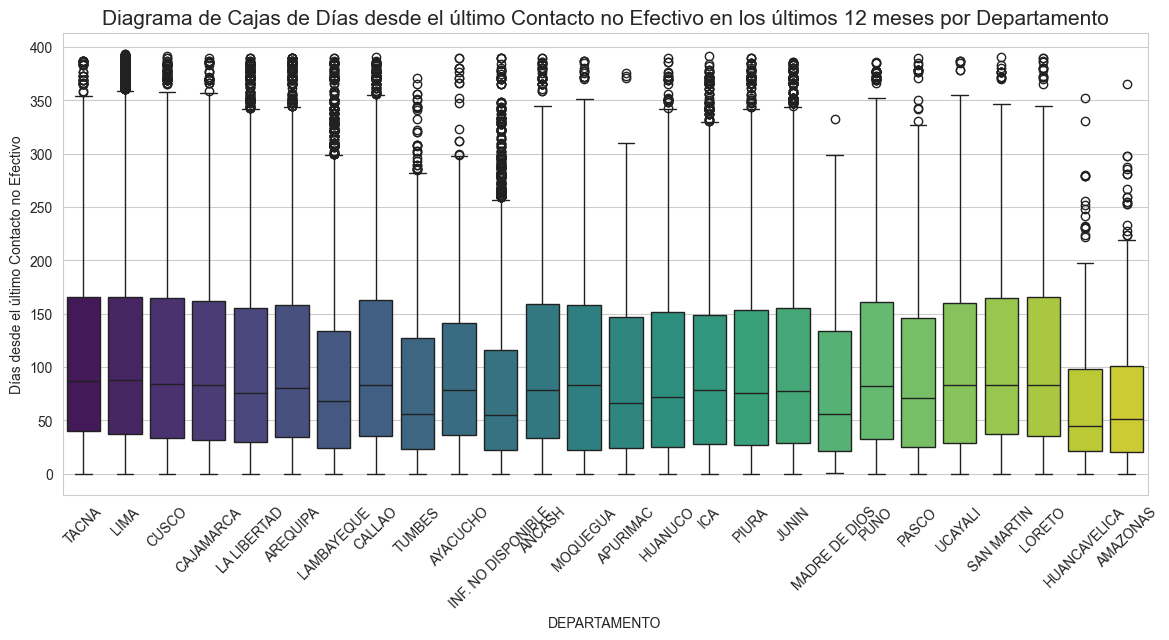

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\1337077047.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='CNE_DIAS12', data=CEFEC, order=orden_seg, palette='Set2')


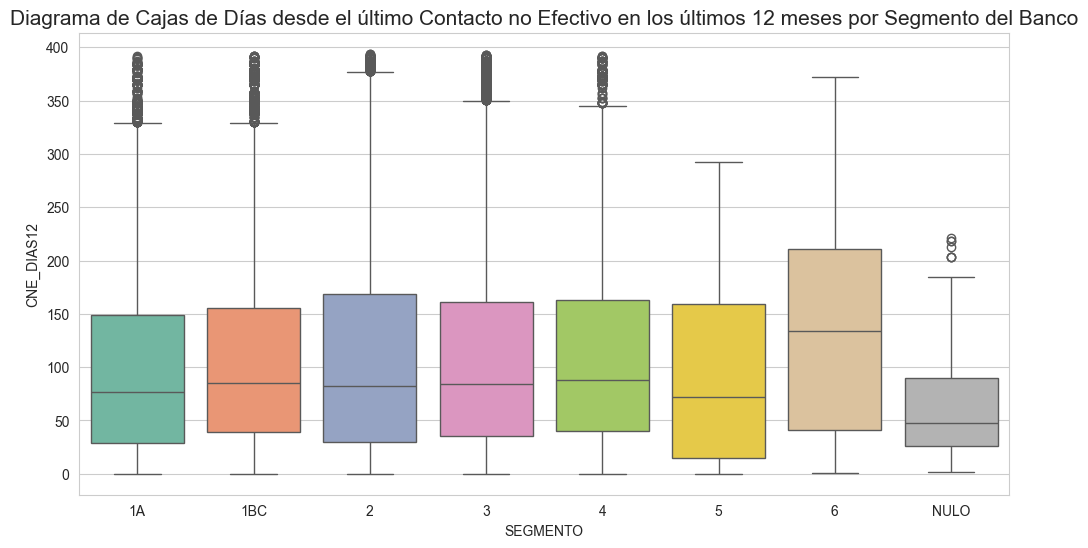

In [67]:

plt.figure(figsize=(14, 6))
sns.boxplot(x='DEPARTAMENTO', y='CNE_DIAS12', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el último Contacto no Efectivo en los últimos 12 meses por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Días desde el último Contacto no Efectivo')
plt.show()

plt.figure(figsize=(12, 6))
orden_seg = ['1A', '1BC', '2', '3', '4', '5', '6', 'NULO']
orden_seg = [s for s in orden_seg if s in CEFEC['SEGMENTO'].unique()]

sns.boxplot(x='SEGMENTO', y='CNE_DIAS12', data=CEFEC, order=orden_seg, palette='Set2')
plt.title('Diagrama de Cajas de Días desde el último Contacto no Efectivo en los últimos 12 meses por Segmento del Banco', fontsize=15)
plt.show()

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\1384815233.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='CNE_DIAS6', data=CEFEC, palette='viridis')


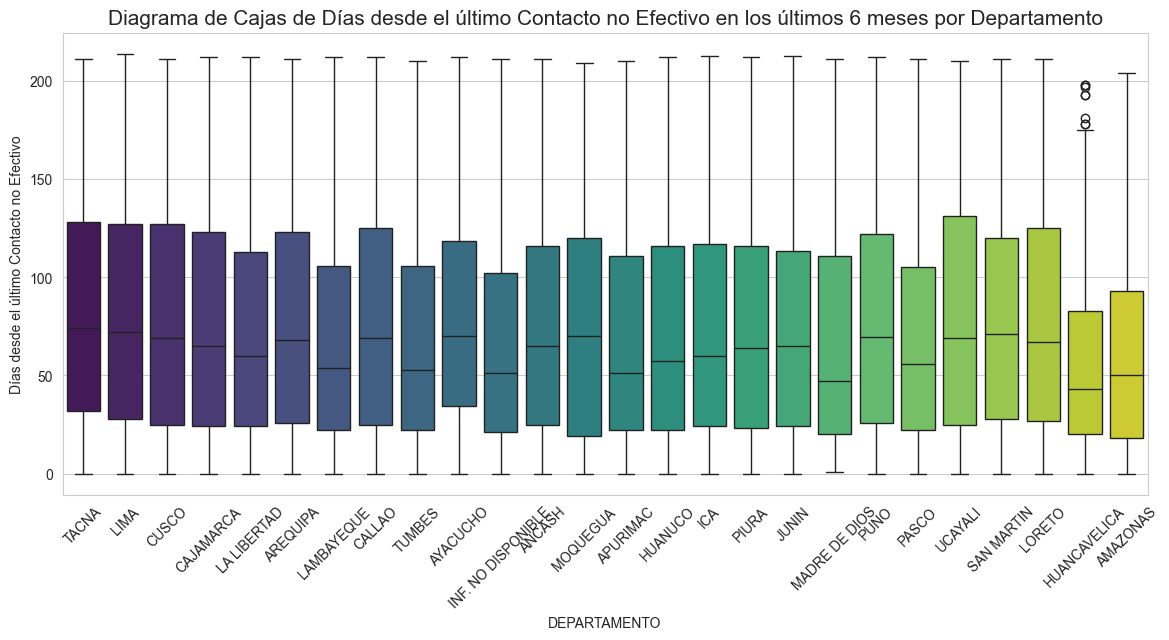

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\1384815233.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='SEGMENTO', y='CNE_DIAS6', data=CEFEC, order=orden_seg, palette='Set2')


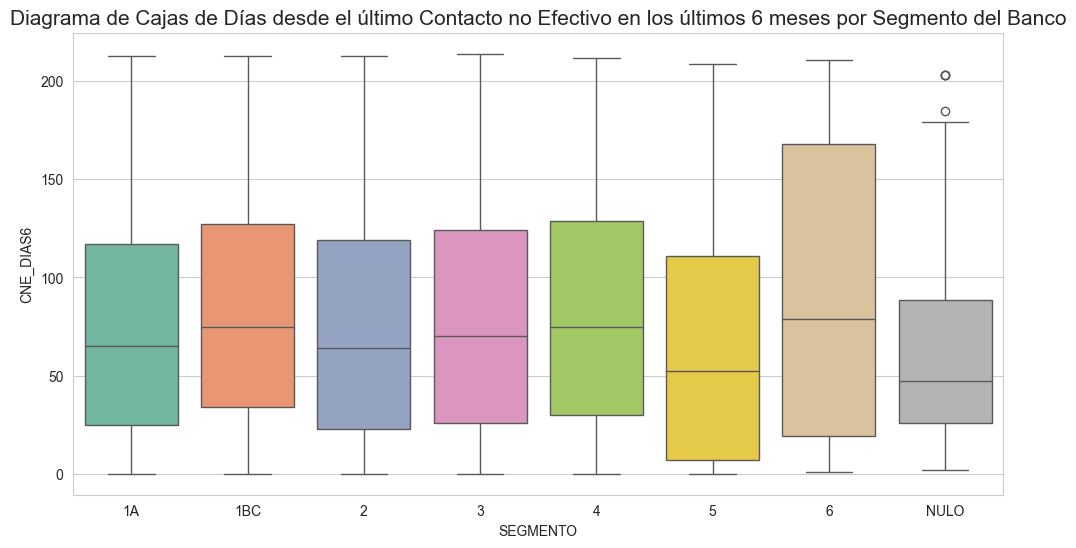

In [68]:

plt.figure(figsize=(14, 6))
sns.boxplot(x='DEPARTAMENTO', y='CNE_DIAS6', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el último Contacto no Efectivo en los últimos 6 meses por Departamento', fontsize=15)
plt.xticks(rotation=45)
plt.ylabel('Días desde el último Contacto no Efectivo')
plt.show()

plt.figure(figsize=(12, 6))
orden_seg = ['1A', '1BC', '2', '3', '4', '5', '6', 'NULO']
orden_seg = [s for s in orden_seg if s in CEFEC['SEGMENTO'].unique()]

sns.boxplot(x='SEGMENTO', y='CNE_DIAS6', data=CEFEC, order=orden_seg, palette='Set2')
plt.title('Diagrama de Cajas de Días desde el último Contacto no Efectivo en los últimos 6 meses por Segmento del Banco', fontsize=15)
plt.show()

In [14]:
cols_cne = ['CNE_DIAS12', 'CNE_DIAS6']

for col in cols_cne:
    mediana_general = CEFEC[col].median()

    CEFEC[col] = CEFEC[col].fillna(mediana_general)
    
    print(f"Variable {col} imputada con mediana general: {mediana_general}")

print("\n--- Imputación por Mediana General completada ---")

Variable CNE_DIAS12 imputada con mediana general: 83.0
Variable CNE_DIAS6 imputada con mediana general: 69.0

--- Imputación por Mediana General completada ---


In [15]:
mediana_cne_dias12 = CEFEC['CNE_DIAS12'].median()
mediana_cne_dias6 = CEFEC['CNE_DIAS6'].median()
print(f"Mediana CNE_DIAS12: {mediana_cne_dias12}")
print(f"Mediana CNE_DIAS6: {mediana_cne_dias6}")  


Mediana CNE_DIAS12: 83.0
Mediana CNE_DIAS6: 69.0


Imputamos igualmente para el caso de Contacto No efectivo

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2868033179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='DIAS_ULT12', data=CEFEC, palette='Set3')


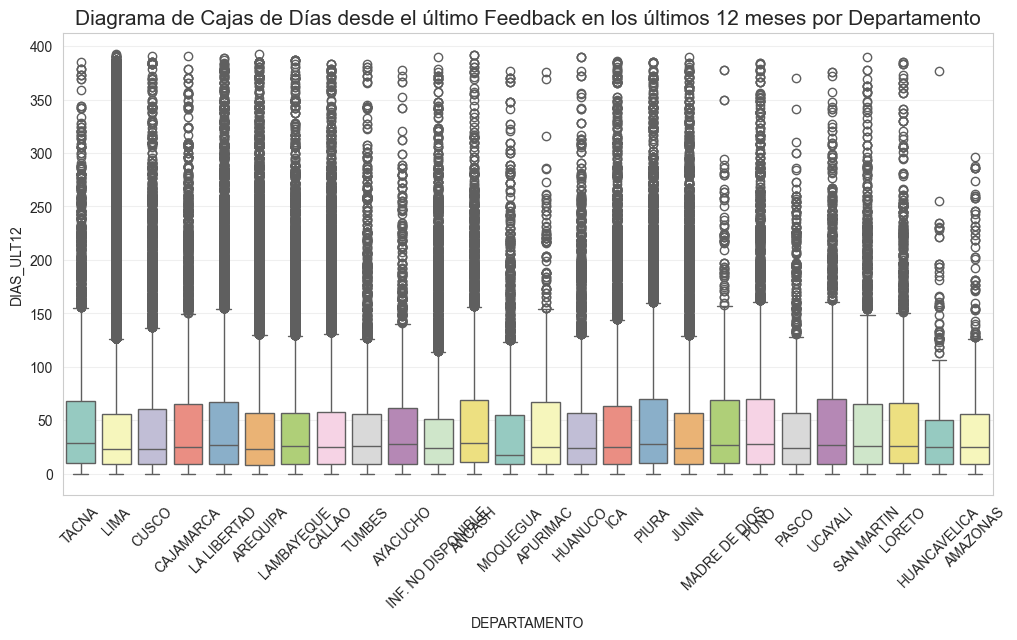

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2868033179.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NUMPRIORIZACION', y='DIAS_ULT12', data=CEFEC, palette='viridis')


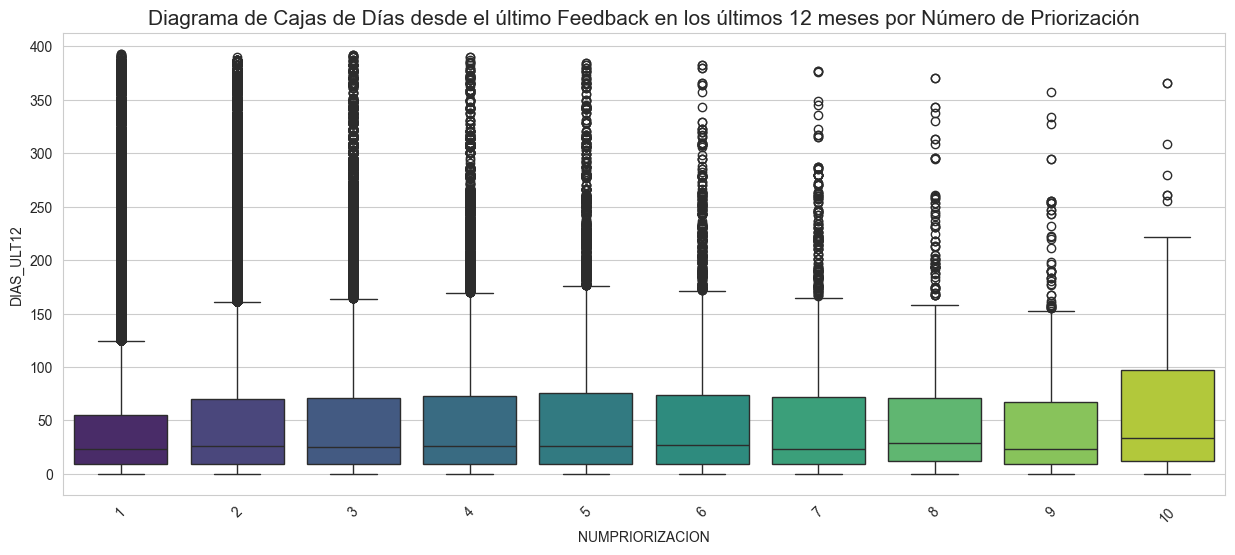

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2868033179.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='DEPARTAMENTO', y='DIAS_BEST12', data=CEFEC, palette='Set3')


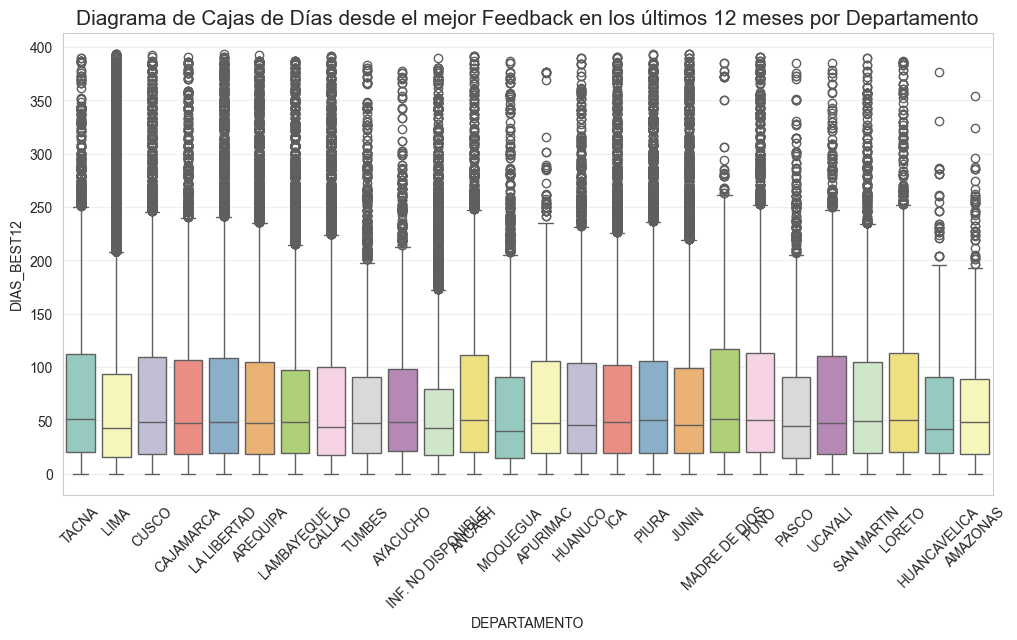

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\2868033179.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='NUMPRIORIZACION', y='DIAS_BEST12', data=CEFEC, palette='viridis')


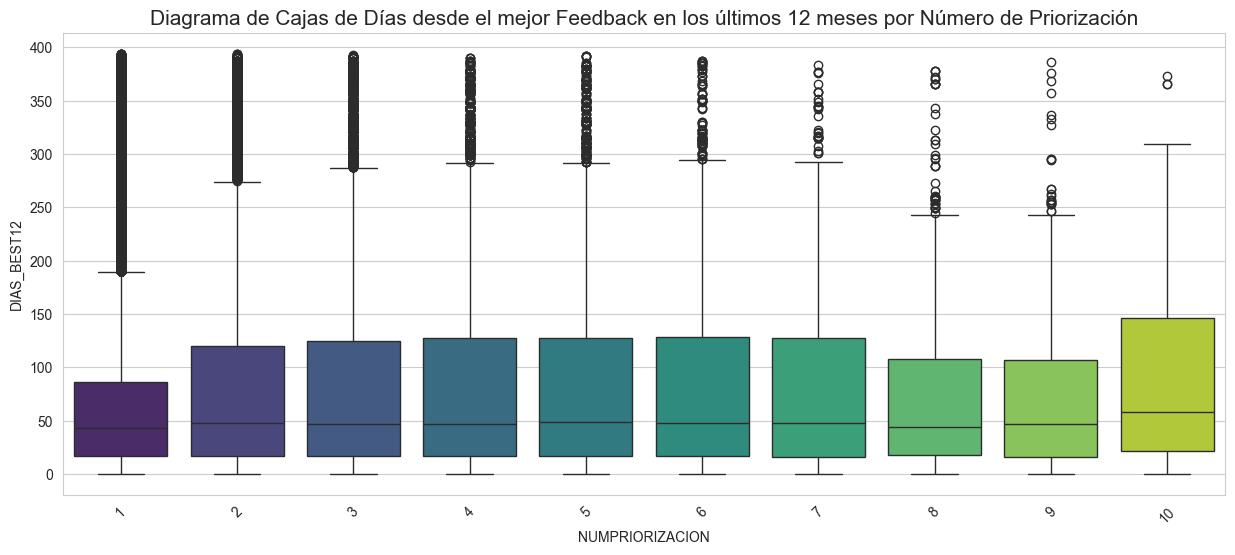

In [102]:
plt.figure(figsize=(12, 6))


sns.boxplot(x='DEPARTAMENTO', y='DIAS_ULT12', data=CEFEC, palette='Set3')
plt.title('Diagrama de Cajas de Días desde el último Feedback en los últimos 12 meses por Departamento', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(x='NUMPRIORIZACION', y='DIAS_ULT12', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el último Feedback en los últimos 12 meses por Número de Priorización', fontsize=15)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(12, 6))


sns.boxplot(x='DEPARTAMENTO', y='DIAS_BEST12', data=CEFEC, palette='Set3')
plt.title('Diagrama de Cajas de Días desde el mejor Feedback en los últimos 12 meses por Departamento', fontsize=15)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(15, 6))
sns.boxplot(x='NUMPRIORIZACION', y='DIAS_BEST12', data=CEFEC, palette='viridis')
plt.title('Diagrama de Cajas de Días desde el mejor Feedback en los últimos 12 meses por Número de Priorización', fontsize=15)
plt.xticks(rotation=45)
plt.show()

In [16]:
cols_cne = ['DIAS_ULT12', 'DIAS_BEST12', 'DIAS_ULT6', 'DIAS_BEST6']

for col in cols_cne:
    mediana_general = CEFEC[col].median()
    
    CEFEC[col] = CEFEC[col].fillna(mediana_general)
    
    print(f"Variable {col} imputada con mediana general: {mediana_general}")


CEFEC['DIAS_BEST12'] = CEFEC['DIAS_BEST12'].astype(int)
CEFEC['DIAS_BEST6'] = CEFEC['DIAS_BEST6'].astype(int)
CEFEC['DIAS_ULT12'] = CEFEC['DIAS_ULT12'].astype(int)
CEFEC['DIAS_ULT6'] = CEFEC['DIAS_ULT6'].astype(int)

print("\n--- Imputación por Mediana General completada ---")

Variable DIAS_ULT12 imputada con mediana general: 24.0
Variable DIAS_BEST12 imputada con mediana general: 44.0
Variable DIAS_ULT6 imputada con mediana general: 22.0
Variable DIAS_BEST6 imputada con mediana general: 41.0

--- Imputación por Mediana General completada ---


In [17]:
dict_medianas_dias = {
    'DIAS_ULT12': CEFEC['DIAS_ULT12'].median(),
    'DIAS_BEST12': CEFEC['DIAS_BEST12'].median(),
    'DIAS_ULT6': CEFEC['DIAS_ULT6'].median(),
    'DIAS_BEST6': CEFEC['DIAS_BEST6'].median()
}

In [18]:
CEFEC['CNE_DISTR12'] = CEFEC['CNE_DISTR12'].fillna(CEFEC['CNE_CTD12'] / CEFEC['TOTGEST12'])
CEFEC['CNE_DISTR6'] = CEFEC['CNE_DISTR6'].fillna(CEFEC['CNE_CTD6'] / CEFEC['TOTGEST6'])
CEFEC['NC_DISTR12'] = CEFEC['NC_DISTR12'].fillna(CEFEC['NC_CTD12'] / CEFEC['TOTGEST12'])
CEFEC['NC_DISTR6'] = CEFEC['NC_CTD6'] / CEFEC['TOTGEST6']

Calculamos las distribuciones correspondientes de No Contacto y Contacto no Efectivo

In [19]:
CEFEC['RANGO_INGRESOS'].mode()

0    Entre S/.1000-4000
Name: RANGO_INGRESOS, dtype: object

In [20]:
CEFEC['RANGO_INGRESOS'] = CEFEC['RANGO_INGRESOS'].replace('NULO', 'Entre S/.1000-4000')

Ahora imputando las variables categóricas, para la variable Rango_Ingresos calculamos su moda, y la reemplazamos por los NULOS

In [21]:
cols_feedback = ['FBK_ULT6', 'FBK_ULT12', 'FBK_BEST6', 'FBK_BEST12']

for col in cols_feedback:

    CEFEC[col] = CEFEC[col].replace('NULO', np.nan)
    
    moda_valor = CEFEC[col].mode()[0]
    
    CEFEC[col] = CEFEC[col].fillna(moda_valor)
    
    print(f"Variable {col}: Se reemplazaron los 'NULO' por la moda: {moda_valor}")


for col in cols_feedback:
    conteo_nulo_texto = (CEFEC[col] == 'NULO').sum()
    print(f"Registros con texto 'NULO' en {col}: {conteo_nulo_texto}")

Variable FBK_ULT6: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_ULT12: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_BEST6: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_BEST12: Se reemplazaron los 'NULO' por la moda: TLV
Registros con texto 'NULO' en FBK_ULT6: 0
Registros con texto 'NULO' en FBK_ULT12: 0
Registros con texto 'NULO' en FBK_BEST6: 0
Registros con texto 'NULO' en FBK_BEST12: 0


Igualmente para las variables FBK_ULT y FBK_BEST

In [22]:
moda_depto = CEFEC[CEFEC['DEPARTAMENTO'] != 'INF. NO DISPONIBLE']['DEPARTAMENTO'].mode()[0]

CEFEC['DEPARTAMENTO'] = CEFEC['DEPARTAMENTO'].replace('INF. NO DISPONIBLE', moda_depto)

print(f"Limpieza completada: Los valores 'INF. NO DISPONIBLE' se reemplazaron por {moda_depto}")

Limpieza completada: Los valores 'INF. NO DISPONIBLE' se reemplazaron por LIMA


Ahora imputamos la variable DEPARTAMENTO

In [23]:
moda_segmento = CEFEC[CEFEC['SEGMENTO'] != 'NULO']['SEGMENTO'].mode()[0]

CEFEC['SEGMENTO'] = CEFEC['SEGMENTO'].replace('NULO', moda_segmento)

print(f"Limpieza completada: Los valores 'NULO' se reemplazaron por {moda_segmento}")

Limpieza completada: Los valores 'NULO' se reemplazaron por 3


Ahora imputamos la variable SEGMENTO

In [24]:
moda_codsala = CEFEC[CEFEC['COD_SALA'] != 'NULO']['COD_SALA'].mode()[0]

CEFEC['COD_SALA'] = CEFEC['COD_SALA'].replace('-999', moda_codsala)

print(f"Limpieza completada: Los valores 'NULO' se reemplazaron por {moda_codsala}")

Limpieza completada: Los valores 'NULO' se reemplazaron por NC


Ahora imputamos la variable COD_SALA

ANÁLISIS DESCRIPTIVO

In [112]:
vars_gestion = ['TOTGEST12', 'TOTGEST6']

tabla_gestion = CEFEC[vars_gestion].describe(percentiles=[.25, .5, .75]).T

tabla_gestion['median'] = CEFEC[vars_gestion].median()
tabla_gestion['cv'] = tabla_gestion['std'] / tabla_gestion['mean']

tabla_gestion = tabla_gestion[['mean', 'median', 'std', 'cv', 'min', 'max']]
tabla_gestion.columns = ['Media', 'Mediana', 'Desv. Estándar', 'Coef. Variación', 'Mínimo', 'Máximo']

print("Análisis Descriptivo de Intensidad de Gestión (6 y 12 meses)")
print(tabla_gestion.round(2))

Análisis Descriptivo de Intensidad de Gestión (6 y 12 meses)
           Media  Mediana  Desv. Estándar  Coef. Variación  Mínimo  Máximo
TOTGEST12   8.65      7.0            6.17             0.71     1.0    30.0
TOTGEST6    7.00      6.0            4.69             0.67     1.0    23.0


Los resultados revelan una estrategia de contacto selectiva. Con una mediana de 6 a 7 gestiones, se observa que el banco mantiene una comunicación activa pero controlada con el cliente promedio, evitando la saturación del canal.

La brecha entre los valores mínimos (1) y máximos (23, 30) evidencia que el banco no gestiona a todos por igual. Existe un grupo crítico de clientes que recibe hasta 4 veces más atención que el promedio, lo que sugiere una priorización basada en el valor potencial o el riesgo del cliente

In [113]:
vars_friccion = ['NC_CTD12', 'NC_DIAS12', 'NC_DISTR12']

desc_friccion = CEFEC[vars_friccion].describe().T

desc_friccion['median'] = CEFEC[vars_friccion].median()

tabla_final = desc_friccion[['mean', 'median', 'std', 'min', 'max']]
print("Análisis Descriptivo de Variables de No Contacto en los últimos 12 meses:")
print(tabla_final.round(2))

Análisis Descriptivo de Variables de No Contacto en los últimos 12 meses:
             mean  median    std  min    max
NC_CTD12     4.45     4.0   3.35  0.0   29.0
NC_DIAS12   59.25    40.0  62.90  0.0  392.0
NC_DISTR12   0.58     0.6   0.26  0.0    1.0


Con una mediana de 4 intentos fallidos, se evidencia una resistencia moderada al contacto. El máximo de 29 identifica un segmento crítico que elude sistemáticamente la comunicación del banco.

Por otro lado, el índice de 0.60 confirma que el "No Contacto" no es un evento aislado, sino un patrón recurrente que abarca más de la mitad del año.

In [114]:
vars_friccion = ['CNE_CTD12', 'CNE_DIAS12','CNE_DISTR12']

desc_friccion = CEFEC[vars_friccion].describe().T

desc_friccion['median'] = CEFEC[vars_friccion].median()

tabla_final = desc_friccion[['mean', 'median', 'std', 'min', 'max']]
print("Análisis Descriptivo de Variables de Contacto No Efectivo en los últimos 12 meses:")
print(tabla_final.round(2))

Análisis Descriptivo de Variables de Contacto No Efectivo en los últimos 12 meses:
              mean  median    std  min    max
CNE_CTD12     2.40    2.00   2.50  0.0   29.0
CNE_DIAS12   92.74   83.00  57.79  0.0  394.0
CNE_DISTR12   0.29    0.29   0.22  0.0    1.0


Con una mediana de 2 intentos anuales donde la llamada es atendida por terceros, se evidencia una fricción operativa que consume recursos sin alcanzar al decisor. Además el 50% de los casos vuelven a ser contactados recién después de 83 días, perdiendo el momentum de venta. Dado que la distribución es de solo 0.29, se concluye que esta ineficiencia es esporádica, sugiriendo que una optimización en los horarios de llamada podría rescatar estas oportunidades perdidas."

In [115]:
var_resencia = ['DIAS_ACT']

tabla_resencia = CEFEC[var_resencia].describe(percentiles=[.25, .5, .75]).T

tabla_resencia['median'] = CEFEC[var_resencia].median()
tabla_resencia['cv'] = tabla_resencia['std'] / tabla_resencia['mean'] 
tabla_resencia['skew'] = CEFEC[var_resencia].skew() # Asimetría

tabla_resencia = tabla_resencia[['mean', 'median', 'std', 'min', 'max']]
tabla_resencia.columns = ['Media', 'Mediana', 'Desv. Estándar', 'Mínimo', 'Máximo']

print("Análisis Descriptivo de los Días de Actividad de los Clientes")
print(tabla_resencia.round(2))

Análisis Descriptivo de los Días de Actividad de los Clientes
           Media  Mediana  Desv. Estándar  Mínimo  Máximo
DIAS_ACT  159.28    111.0          145.61     0.0   673.0


Con una mediana de 111 días, se observa que la mitad de los números telefónicos en la base de datos han mantenido actividad reciente en un periodo cercano a los cuatro meses, lo que sugiere una ventana de oportunidad razonable para la gestión comercial. Sin embargo, la alta desviación estándar (145.61) y el valor máximo de 673 días confirman una gran heterogeneidad en la antigüedad del dato; existe un segmento con información muy antigua que podría incrementar las tasas de contacto fallido.

In [116]:
resumen_dias_best = CEFEC.groupby('FBK_BEST12')['DIAS_BEST12'].agg(['mean', 'median', 'std']).reset_index()
print("Análisis Descriptivo de los Días desde el Mejor Feedback por Categoría:")
print(resumen_dias_best.round(2))

Análisis Descriptivo de los Días desde el Mejor Feedback por Categoría:
  FBK_BEST12    mean  median    std
0        COB  167.53   163.0  79.07
1        IVR  102.44    78.0  85.22
2        TLV   62.86    44.0  65.47


 En el canal de Televentas (TLV), se observa la mayor frescura del dato con una mediana de 44 días, lo que posiciona a la venta telefónica directa como el canal con resultados positivos más inmediatos y recurrentes. Por otro lado, el canal de IVR (Respuesta de Voz Interactiva) muestra una inactividad moderada con una mediana de 78 días, reflejando que las interacciones automatizadas tardan más en consolidar un 'mejor resultado' o tienen una frecuencia de éxito menor. Finalmente, el canal de Cobranzas (COB) presenta la mayor antigüedad con una mediana de 163 días, lo cual es coherente con su naturaleza: los resultados positivos en este frente (como acuerdos de pago o regularizaciones) suelen ser procesos de maduración más lenta y menos frecuentes que una venta directa.

ANÁLISIS GRÁFICOS

C:\Users\stefa\AppData\Local\Temp\ipykernel_6588\1336009243.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


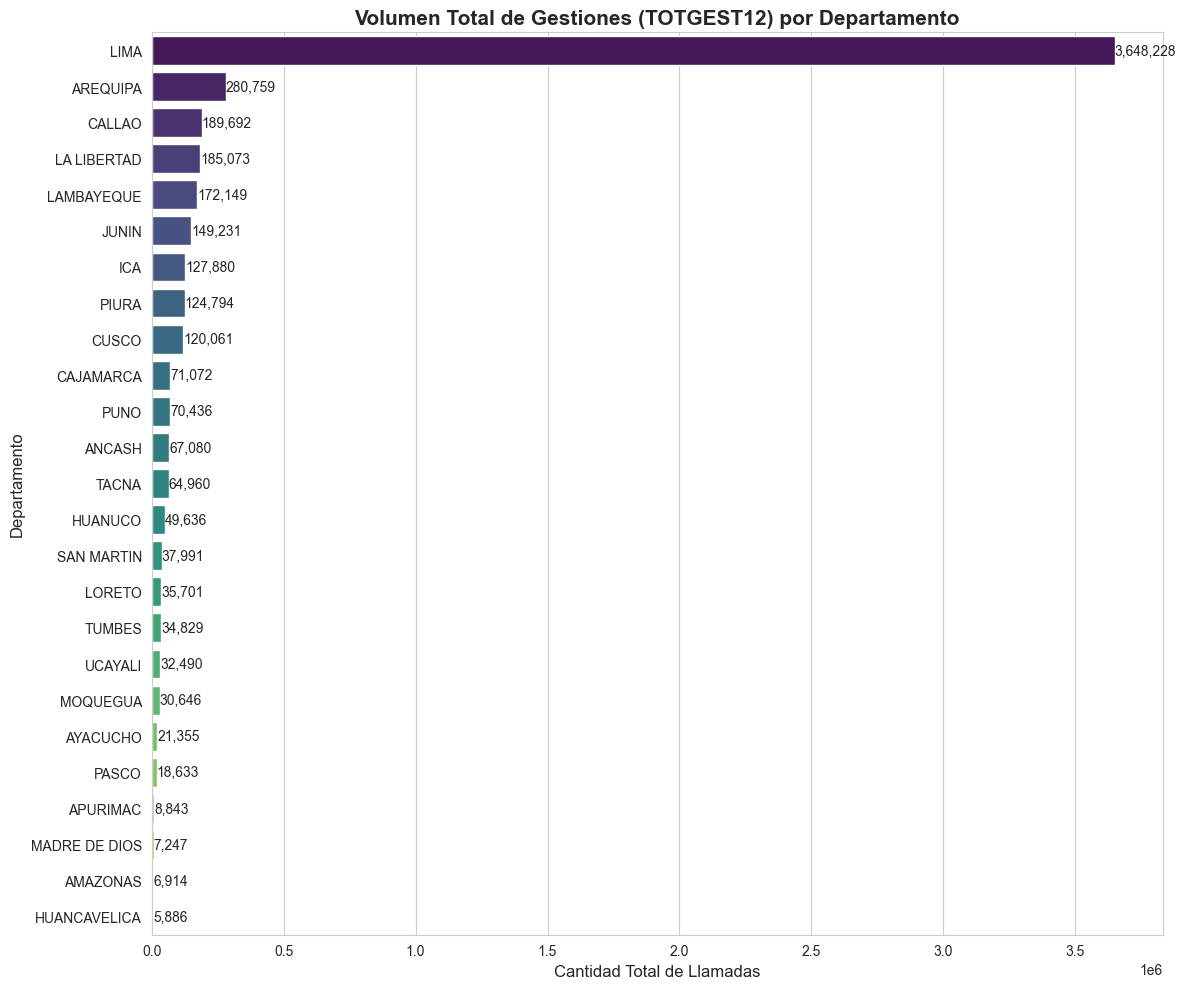

In [ ]:
df_gest_depto = CEFEC.groupby('DEPARTAMENTO')['TOTGEST12'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

ax = sns.barplot(
    data=df_gest_depto, 
    x='TOTGEST12', 
    y='DEPARTAMENTO', 
    palette='viridis' 
)

for p in ax.patches:
    width = p.get_width()
    ax.text(width + 500, p.get_y() + p.get_height()/2, 
            f'{int(width):,}', 
            ha='left', va='center', fontsize=10)

plt.title('Volumen Total de Gestiones Anual por Departamento', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad Total de Llamadas', fontsize=12)
plt.ylabel('Departamento', fontsize=12)

plt.tight_layout()
plt.show()

Se revela una marcada hegemonía de la capital, donde Lima concentra más de 3.6 millones de contactos, superando exponencialmente a polos regionales como Arequipa (280,759), Callao (189,692) y La Libertad (185,073). Esta centralización del esfuerzo comercial refleja la densidad de la cartera de clientes y la actividad económica del país, contrastando drásticamente con departamentos como Apurímac, Amazonas o Huancavelica, donde la penetración de los canales de gestión es mínima.

C:\Users\stefa\AppData\Local\Temp\ipykernel_6588\91887329.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


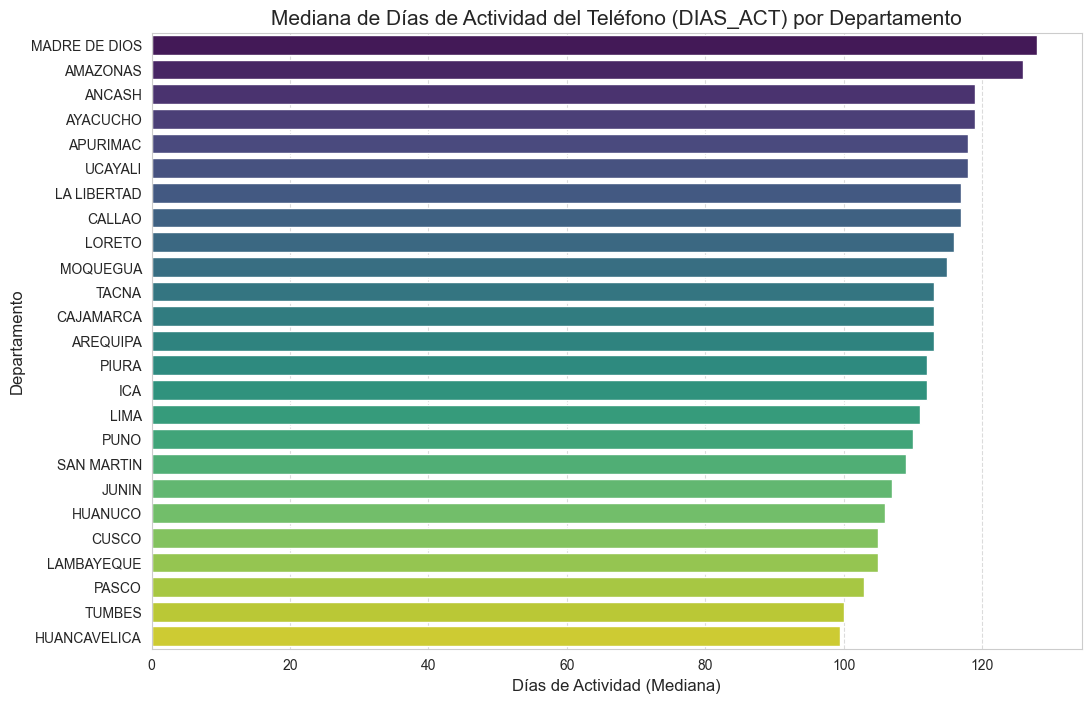

In [ ]:
plt.figure(figsize=(12, 8))

orden_dept = CEFEC.groupby('DEPARTAMENTO')['DIAS_ACT'].median().sort_values(ascending=False).index

sns.barplot(
    data=CEFEC, 
    y='DEPARTAMENTO', 
    x='DIAS_ACT', 
    order=orden_dept, 
    estimator='median',
    palette='viridis',
    errorbar=None 
)

# 4. Personalización técnica
plt.title('Mediana de Días de Actividad del Teléfono (DIAS_ACT) por Departamento', fontsize=15)
plt.xlabel('Días de Actividad (Mediana)', fontsize=12)
plt.ylabel('Departamento', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.show()

Se revela una distribución notablemente más homogénea que el volumen de gestiones, con valores que oscilan en un rango estrecho entre los 100 y 130 días. A diferencia del gráfico de barras anterior, aquí los departamentos con menor volumen comercial, como Madre de Dios y Amazonas, lideran la tabla con las medianas de actividad más altas (cercanas a los 125 días), lo que sugiere que en estas regiones la base de datos es más estable o menos rotativa. Por el contrario, departamentos como Huancavelica y Tumbes presentan la información más 'fresca' o reciente, con medianas cercanas a los 100 días

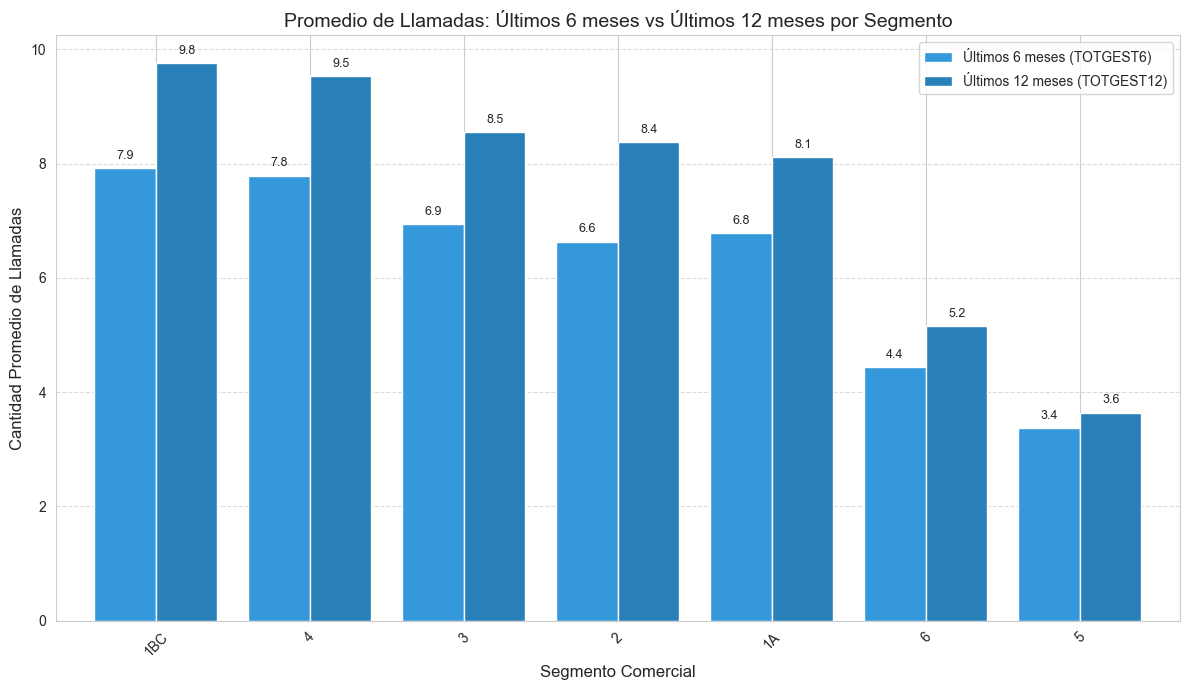

In [ ]:
df_gestion = CEFEC.groupby('SEGMENTO')[['TOTGEST6', 'TOTGEST12']].mean().sort_values(by='TOTGEST12', ascending=False)

ax = df_gestion.plot(kind='bar', figsize=(12, 7), width=0.8, color=['#3498db', '#2980b9'])

plt.title('Promedio de Llamadas: Últimos 6 meses vs Últimos 12 meses por Segmento', fontsize=14)
plt.xlabel('Segmento Comercial', fontsize=12)
plt.ylabel('Cantidad Promedio de Llamadas', fontsize=12)
plt.xticks(rotation=45)
plt.legend(['Últimos 6 meses (TOTGEST6)', 'Últimos 12 meses (TOTGEST12)'])
plt.grid(axis='y', linestyle='--', alpha=0.7)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                xytext=(0, 9), 
                textcoords='offset points',
                fontsize=9)

plt.tight_layout()
plt.show()

El promedio de los últimos 6 meses representa, en la mayoría de los segmentos, más del 80% del volumen anual. Esta concentración temporal evidencia una aceleración reciente de la actividad comercial, sugiriendo que las campañas de venta se han intensificado en el periodo más cercano a la toma de datos. Por otro lado, los segmentos 6 y 5 muestran promedios significativamente menores, lo que refleja una estrategia de contacto pasiva o de bajo costo para perfiles de menor prioridad

C:\Users\stefa\AppData\Local\Temp\ipykernel_22568\2497188571.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


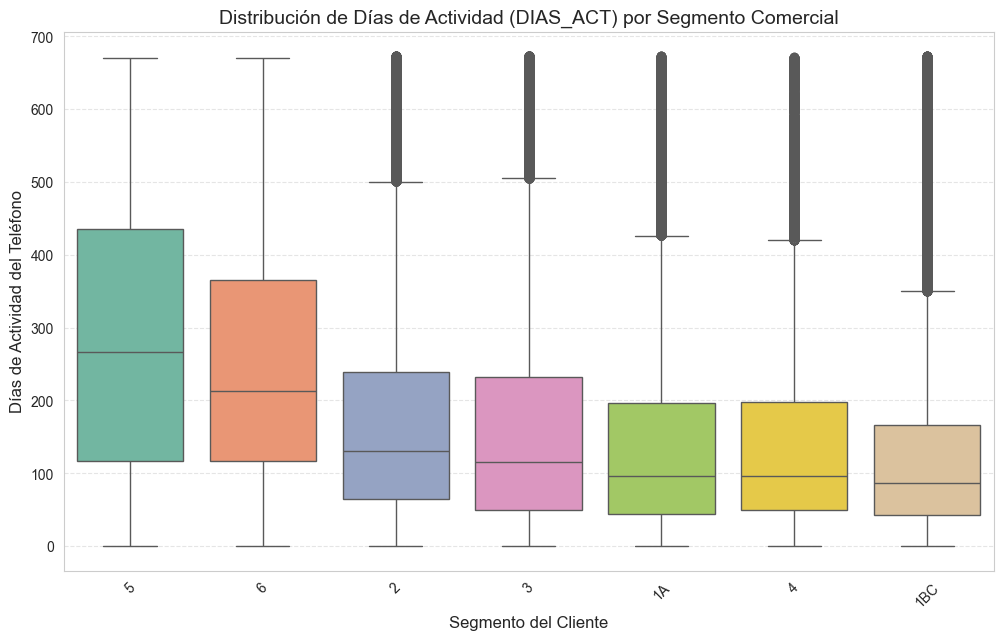

In [ ]:
plt.figure(figsize=(12, 7))

orden_segmento = CEFEC.groupby('SEGMENTO')['DIAS_ACT'].median().sort_values(ascending=False).index

# 3. Crear el Boxplot
sns.boxplot(
    data=CEFEC, 
    x='SEGMENTO', 
    y='DIAS_ACT', 
    order=orden_segmento, 
    palette='Set2'
)

# 4. Personalización y estética
plt.title('Distribución de Días de Actividad (DIAS_ACT) por Segmento', fontsize=14)
plt.xlabel('Segmento del Cliente', fontsize=12)
plt.ylabel('Días de Actividad del Teléfono', fontsize=12)
plt.xticks(rotation=45) 
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Se observa que los segmentos 5 y 6 presentan las cajas más elevadas y extendidas, con medianas superiores a los 250 días de actividad acumulada, lo que indica que estos perfiles poseen líneas telefónicas con mayor antigüedad y permanencia en la base de datos. En contraste, los segmentos de alto valor como 1BC, 4 y 1A muestran distribuciones más bajas (medianas menores a 100 días), lo que sugiere una rotación más alta o una captación más reciente de estos clientes dentro del canal.

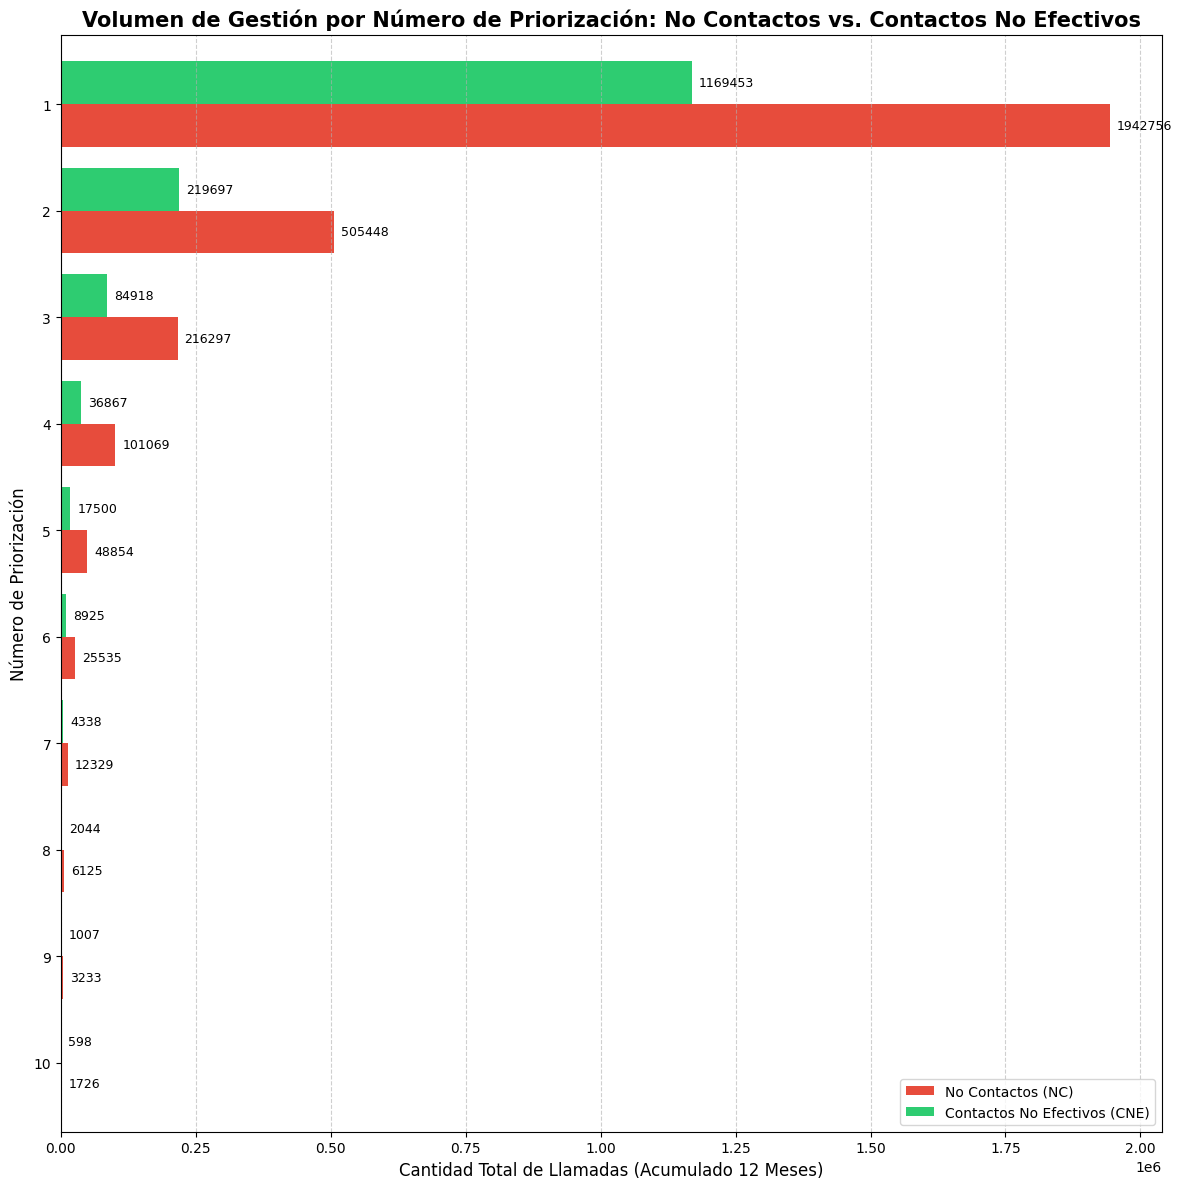

--- RESUMEN DE GESTIÓN POR NÚMERO DE PRIORIZACIÓN ---
                 NC_CTD12  CNE_CTD12  Tasa_Efectividad_%
NUMPRIORIZACION                                         
1                 1942756    1169453           37.576300
2                  505448     219697           30.296975
3                  216297      84918           28.191823
4                  101069      36867           26.727613
5                   48854      17500           26.373693
7                   12329       4338           26.027479
6                   25535       8925           25.899594
10                   1726        598           25.731497
8                    6125       2044           25.021422
9                    3233       1007           23.750000


In [43]:
df_depto = CEFEC.groupby('NUMPRIORIZACION')[['NC_CTD12', 'CNE_CTD12']].sum().sort_values(by='NC_CTD12')

ax = df_depto.plot(kind='barh', figsize=(12, 12), color=['#e74c3c', '#2ecc71'], width=0.8)

plt.title('Volumen de Gestión por Número de Priorización: No Contactos vs. Contactos No Efectivos', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad Total de Llamadas (Acumulado 12 Meses)', fontsize=12)
plt.ylabel('Número de Priorización', fontsize=12)
plt.legend(['No Contactos (NC)', 'Contactos No Efectivos (CNE)'], loc='lower right')
plt.grid(axis='x', linestyle='--', alpha=0.6)

for p in ax.patches:
    ax.annotate(f'{int(p.get_width())}', 
                (p.get_width(), p.get_y() + p.get_height() / 2.), 
                ha='left', va='center', xytext=(5, 0), textcoords='offset points', fontsize=9)

plt.tight_layout()
plt.show()

df_depto['Total_Gestiones'] = df_depto['NC_CTD12'] + df_depto['CNE_CTD12']
df_depto['Tasa_Efectividad_%'] = (df_depto['CNE_CTD12'] / df_depto['Total_Gestiones']) * 100

print("--- RESUMEN DE GESTIÓN POR NÚMERO DE PRIORIZACIÓN ---")
print(df_depto[['NC_CTD12', 'CNE_CTD12', 'Tasa_Efectividad_%']].sort_values(by='Tasa_Efectividad_%', ascending=False))

Se observa una concentración masiva en la Prioridad 1, que agrupa la mayor cantidad tanto de No Contactos (NC) como de Contactos Efectivos (CNE), lo que valida este nivel como la fuente primaria de información del banco. Además en prácticamente todos los niveles de prioridad, el volumen de No Contactos (rojo) supera ampliamente al de Contactos Efectivos (verde), manteniendo una relación de casi 2 a 1 en los niveles superiores. Esta tendencia decreciente y proporcional a lo largo de los 10 niveles confirma que la regla de priorización es coherente

In [117]:
CEFEC.columns

Index(['NUMPRIORIZACION', 'NC_DISTR12', 'TOTGEST6', 'TOTGEST12', 'IDGRUPO',
       'DIAS_ACT', 'FBK_ULT6', 'FBK_ULT12', 'FBK_BEST6', 'DIAS_BEST6',
       'DIAS_ULT6', 'FBK_BEST12', 'DIAS_BEST12', 'DIAS_ULT12', 'CNE_CTD12',
       'CNE_CTD6', 'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12', 'CNE_DIAS12',
       'NC_CTD12', 'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6', 'COD_SALA',
       'FEC_LLAMADA', 'PROVINCIA', 'DEPARTAMENTO', 'INGRESO_NETO_VIGENTE',
       'INGRESO_BRUTO', 'SEGMENTO', 'RANGO_INGRESOS', 'TARGET', 'NC_DISTR6',
       'NGRESRANGO_IOS'],
      dtype='object')

CONCLUSIONES ANÁLISIS DESCRIPTIVO Y GRÁFICO

El diagnóstico integral de la cartera revela que la gestión de contactos del banco opera bajo un modelo de alta selectividad y centralización estratégica, donde el éxito está condicionado por la frescura del dato y la intensidad de la gestión.

Eficiencia Operativa y Barreras de Contacto: El banco mantiene una comunicación activa pero controlada (6-7 gestiones promedio), enfrentando una resistencia moderada al contacto donde el fenómeno del "No Contacto" es un patrón recurrente para más del 50% de la base anual. La ineficiencia detectada en las llamadas atendidas por terceros (CNE), con una pérdida de momentum de más de 80 días, representa una oportunidad de optimización horaria para rescatar oportunidades de venta.

Segmentación y Ciclos de Vida: Existe una clara diferenciación en la maduración de los canales; mientras que Televentas ofrece la mayor inmediatez (44 días de recencia), Cobranzas requiere ciclos más largos (163 días) para consolidar resultados positivos. Esto se alinea con una estrategia de segmentación donde los clientes de mayor valor muestran una rotación más alta o captación más reciente, contrastando con segmentos de menor prioridad que presentan datos más antiguos y estables.

Geografía y Estructura de Priorización: La actividad comercial presenta una hegemonía centralista en Lima, aunque las regiones con menor volumen muestran una base de datos más estable. La regla de priorización actual del banco demuestra ser coherente, concentrando la mayor carga operativa en los Niveles superiores.

VISUALIZACIÓN DEL TARGET

C:\Users\stefa\AppData\Local\Temp\ipykernel_22568\3638859585.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='TARGET',data=CEFEC,palette='RdBu_r');


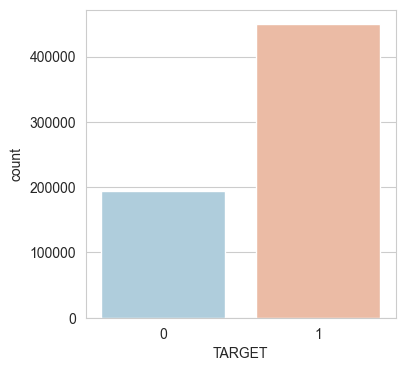

In [58]:
sns.set_style('whitegrid')
plt.figure(figsize=(4,4))
sns.countplot(x='TARGET',data=CEFEC,palette='RdBu_r');

Se revela un desbalance de clases con una predominancia de la categoría positiva (1), la cual tiene mas del doble del volumen de datos que la categoría negativa (0)

RELACIÓN DEL TARGET CON LAS VARIABLES PREDICTORAS

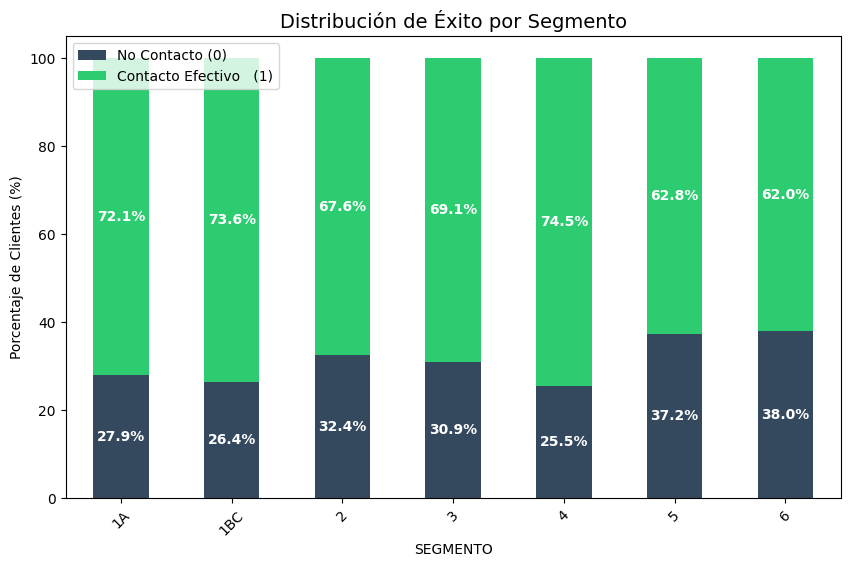

In [27]:
tabla_target = pd.crosstab(CEFEC['SEGMENTO'], CEFEC['TARGET'], normalize='index') * 100

ax = tabla_target.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#34495e', '#2ecc71'])

plt.title('Distribución de Éxito por Segmento', fontsize=14)
plt.ylabel('Porcentaje de Clientes (%)')
plt.legend(['No Contacto (0)', 'Contacto Efectivo   (1)'], loc='upper left')

for p in ax.patches:
    width, height = p.get_width(), p.get_height()
    x, y = p.get_xy() 
    if height > 5: # Solo mostrar si hay espacio
        ax.text(x+width/2, y+height/2, f'{height:.1f}%', ha='center', va='center', color='white', fontweight='bold')

plt.xticks(rotation=45)
plt.show()

Se observa que los segmento de alto valor lideran las tasas de éxito con un porcentaje de entre 67 y 75% de contactos efectivos. Este comportamiento contrasta significativamente con los segmentos de bajo valor (5 y 6), donde la tasa de éxito cae hasta un 62.0%, registrando a su vez los niveles más altos de contactos no efectivos (38.0%).

C:\Users\stefa\AppData\Local\Temp\ipykernel_30240\817114720.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_target = CEFEC.groupby('INGRESO_BIN')['TARGET'].mean() * 100


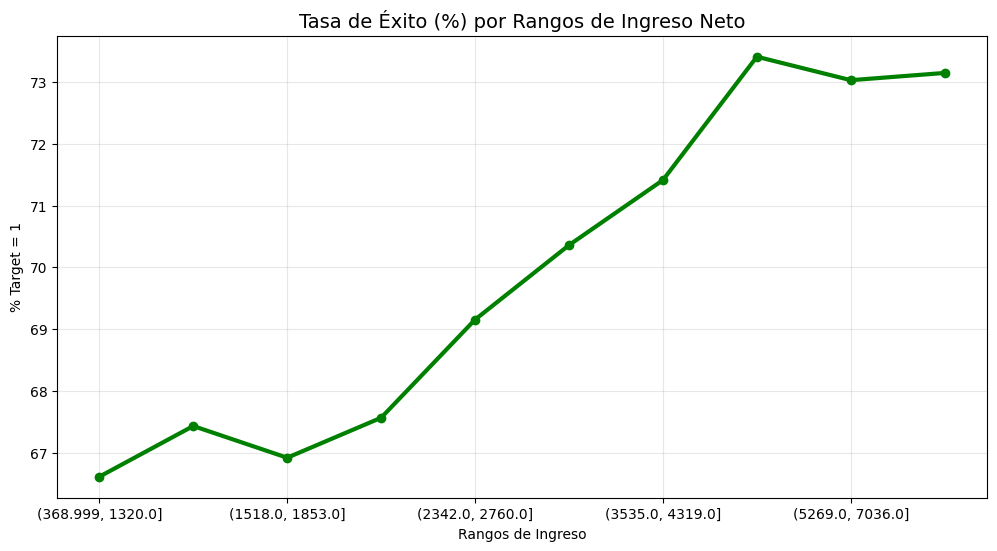

In [26]:
CEFEC['INGRESO_BIN'] = pd.qcut(CEFEC['INGRESO_NETO_VIGENTE'], q=10, duplicates='drop')

tasa_target = CEFEC.groupby('INGRESO_BIN')['TARGET'].mean() * 100

plt.figure(figsize=(12, 6))
tasa_target.plot(kind='line', marker='o', linewidth=3, color='green')
plt.title('Tasa de Éxito (%) por Rangos de Ingreso Neto', fontsize=14)
plt.ylabel('% Target = 1')
plt.xlabel('Rangos de Ingreso')
plt.grid(True, alpha=0.3)
plt.show()

Se revela una tendencia monótona creciente: a mayor nivel de ingresos, mayor es la probabilidad de lograr un Contacto Efectivo. Se observa que los clientes en los deciles de ingresos más bajos presentan tasas de éxito cercanas al 66.5%, mientras que los niveles de ingresos más altos (superiores a los 5,000 soles) alcanzan picos de éxito de hasta un 73.5%. Esta pendiente positiva sugiere que los clientes con mayor capacidad económica tienden a poseer una mayor estabilidad en sus datos de contacto y una menor incidencia de No Contactos o filtros por terceros

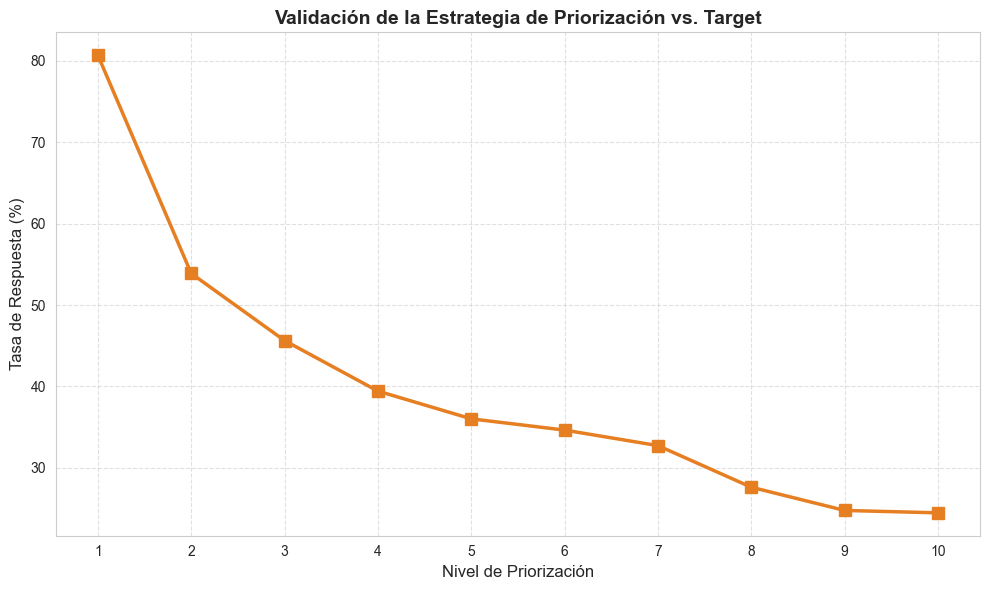

In [ ]:
tasa_prioridad = CEFEC.groupby('NUMPRIORIZACION')['TARGET'].mean() * 100

plt.figure(figsize=(10, 6))
tasa_prioridad.plot(kind='line', marker='s', color='#e67e22', linewidth=2.5, markersize=8)

plt.title('Validación de la Estrategia de Priorización vs. Target', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Priorización', fontsize=12)
plt.ylabel('Tasa de Respuesta (%)', fontsize=12)
plt.xticks(CEFEC['NUMPRIORIZACION'].unique()) 
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Se observa que el Nivel 1 alcanza una tasa de éxito sobresaliente de aproximadamente 80%, lo que valida la alta calidad de los números telefónicos provenientes de los canales principales. A medida que el número de prioridad aumenta (indicando menor importancia del canal), la tasa de éxito cae drásticamente hasta situarse por debajo del 30% en los niveles 9 y 10.

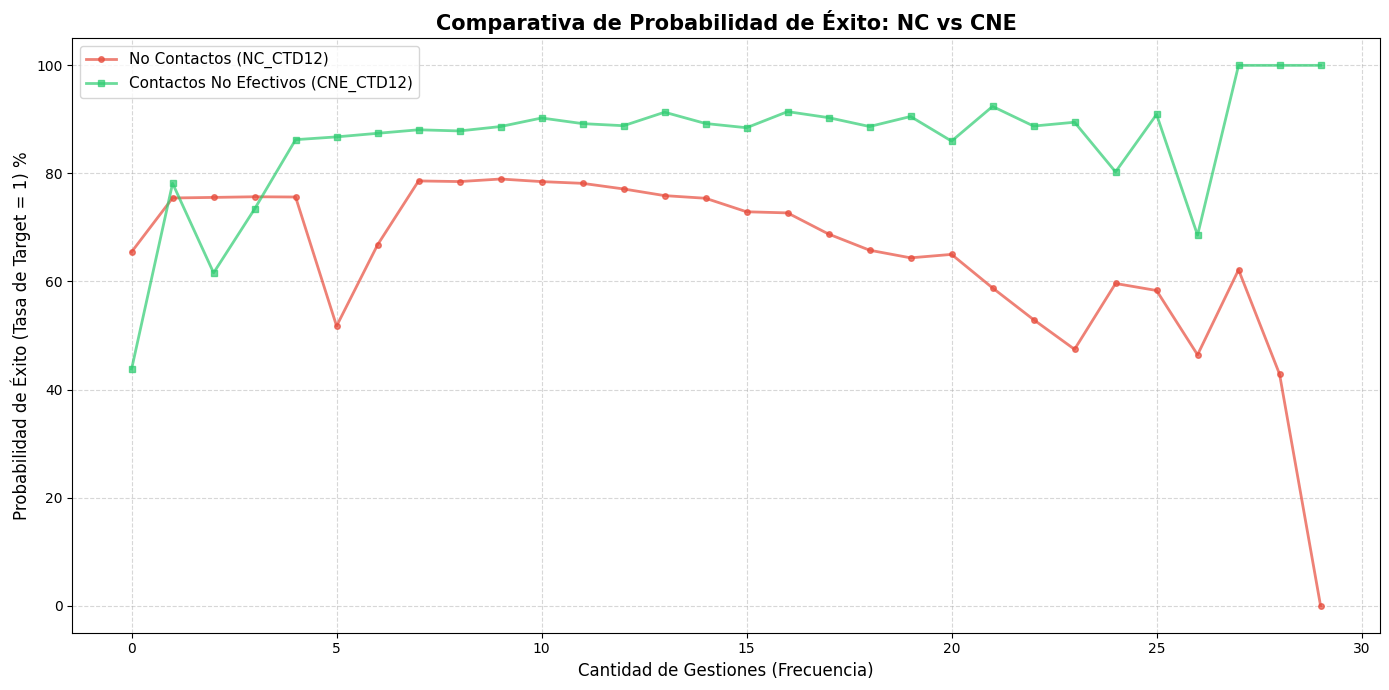

In [28]:
# 1. Calculamos la probabilidad (media del target) por cada valor individual
# Multiplicamos por 100 para tener el porcentaje (%)
prob_nc = CEFEC.groupby('NC_CTD12')['TARGET'].mean() * 100
prob_cne = CEFEC.groupby('CNE_CTD12')['TARGET'].mean() * 100

# 2. Configuramos la figura
plt.figure(figsize=(14, 7))

# 3. Graficamos la línea de No Contactos (NC)
plt.plot(prob_nc.index, prob_nc.values, label='No Contactos (NC_CTD12)', 
         color='#e74c3c', linewidth=2, marker='o', markersize=4, alpha=0.7)

# 4. Graficamos la línea de Contactos Efectivos (CNE)
plt.plot(prob_cne.index, prob_cne.values, label='Contactos No Efectivos (CNE_CTD12)', 
         color='#2ecc71', linewidth=2, marker='s', markersize=4, alpha=0.7)

# 5. Personalización y Estética
plt.title('Comparativa de Probabilidad de Éxito: NC vs CNE', fontsize=15, fontweight='bold')
plt.xlabel('Cantidad de Gestiones (Frecuencia)', fontsize=12)
plt.ylabel('Probabilidad de Éxito (Tasa de Target = 1) %', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Opcional: Limitar el eje X si hay valores extremadamente raros (ej. 100 llamadas)
# para que la parte importante del gráfico se vea mejor.
# plt.xlim(0, 50) 

plt.tight_layout()
plt.show()

Se observa que la probabilidad de éxito ante la acumulación de Contactos No Efectivos (CNE) —casos donde el teléfono es atendido por terceros— se mantiene estable y tiende al alza, superando el 80% conforme aumenta la frecuencia. Esto sugiere que, si bien hay una barrera inicial con filtros familiares o de terceros, la línea permanece activa y el titular es eventualmente ubicable. Por el contrario, la curva de No Contactos (NC) muestra un deterioro progresivo a partir de las 15 gestiones, con una caída drástica hacia el final de la serie. Este fenómeno indica un agotamiento del dato: la acumulación de llamadas no contestadas es un síntoma de números inactivos o abandonados

C:\Users\stefa\AppData\Local\Temp\ipykernel_22568\495672465.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=CEFEC, x='TARGET', y='TOTGEST12', palette=['#e74c3c', '#2ecc71'])


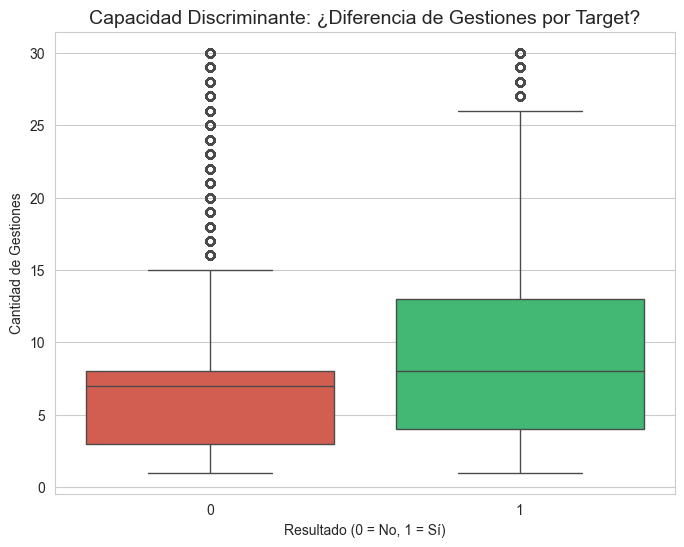

In [63]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=CEFEC, x='TARGET', y='TOTGEST12', palette=['#e74c3c', '#2ecc71'])

plt.title('Capacidad Discriminante: ¿Diferencia de Gestiones por Target?', fontsize=14)
plt.xlabel('Resultado (0 = No, 1 = Sí)')
plt.ylabel('Cantidad de Gestiones')
plt.show()

Se observa que los casos de éxito (Target 1) presentan una mediana de gestiones superior y un rango intercuartílico más extendido en comparación con los casos fallidos (Target 0). Mientras que la mayoría de los contactos fallidos se concentran por debajo de las 8 gestiones, los registros positivos muestran una distribución que alcanza con frecuencia las 13 o 15 gestiones, lo que sugiere que la persistencia operativa es un factor determinante para lograr el contacto con el titular.

In [48]:
df1=CEFEC

C:\Users\stefa\AppData\Local\Temp\ipykernel_26908\139809562.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  analisis_tramos = df1.groupby('tramo_20_dias')['TARGET'].mean() * 100


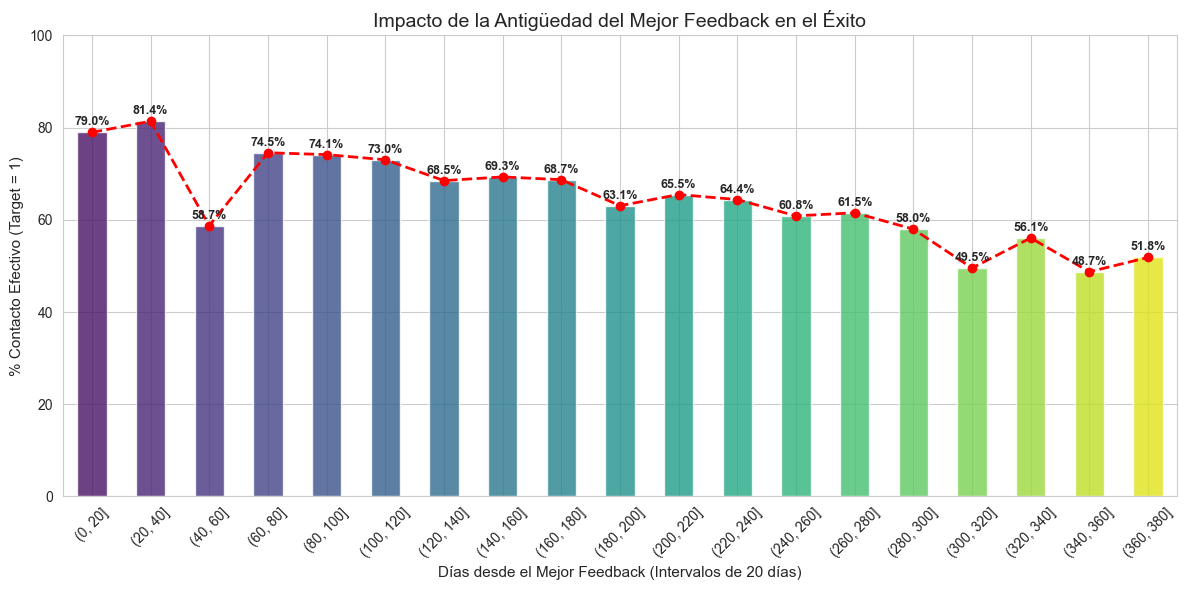

In [49]:
bins = np.arange(0, 381, 20)
df1['tramo_20_dias'] = pd.cut(df1['DIAS_BEST12'], bins=bins)

analisis_tramos = df1.groupby('tramo_20_dias')['TARGET'].mean() * 100

# 3. Graficar
plt.figure(figsize=(12, 6))
sns.set_style("whitegrid")

colores = sns.color_palette("viridis", len(analisis_tramos))
analisis_tramos.plot(kind='bar', color=colores, alpha=0.8)

plt.plot(range(len(analisis_tramos)), analisis_tramos.values, 
         color='red', marker='o', linestyle='--', linewidth=2)

plt.title('Impacto de la Antigüedad del Mejor Feedback en el Éxito', fontsize=14)
plt.xlabel('Días desde el Mejor Feedback (Intervalos de 20 días)', fontsize=11)
plt.ylabel('% Contacto Efectivo (Target = 1)', fontsize=11)
plt.xticks(rotation=45)
plt.ylim(0, 100)

for i, v in enumerate(analisis_tramos):
    plt.text(i, v + 1.5, f"{v:.1f}%", ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

Se revela una tendencia decreciente, donde se observa que a medida que aumentan los días desde el último mejor feedback, la tasa de éxito (Target=1) disminuye significativamente. Esto sugiere que la frescura del feedback es un factor crítico para lograr contactos efectivos, y resalta la importancia de mantener una comunicación constante y actualizada con los clientes para maximizar las probabilidades de éxito.   

BALANCEO DE DATOS Y CORRIDA DE LOS MODELOS

In [25]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [26]:
CEFEC['DEPARTAMENTO'].unique()

array(['TACNA', 'LIMA', 'CUSCO', 'CAJAMARCA', 'LA LIBERTAD', 'AREQUIPA',
       'LAMBAYEQUE', 'CALLAO', 'TUMBES', 'AYACUCHO', 'ANCASH', 'MOQUEGUA',
       'APURIMAC', 'HUANUCO', 'ICA', 'PIURA', 'JUNIN', 'MADRE DE DIOS',
       'PUNO', 'PASCO', 'UCAYALI', 'SAN MARTIN', 'LORETO', 'HUANCAVELICA',
       'AMAZONAS'], dtype=object)

In [27]:
regiones_peru = {
    # NORTE
    'TUMBES': 'NORTE', 'PIURA': 'NORTE', 'LAMBAYEQUE': 'NORTE', 
    'LA LIBERTAD': 'NORTE', 'CAJAMARCA': 'NORTE', 'AMAZONAS': 'NORTE',
    
    # CENTRO
    'LIMA': 'CENTRO', 'CALLAO': 'CENTRO', 'ANCASH': 'CENTRO', 
    'HUANUCO': 'CENTRO', 'PASCO': 'CENTRO', 'JUNIN': 'CENTRO', 
    'HUANCAVELICA': 'CENTRO', 'ICA': 'CENTRO',
    
    # SUR
    'AREQUIPA': 'SUR', 'MOQUEGUA': 'SUR', 'TACNA': 'SUR', 
    'CUSCO': 'SUR', 'APURIMAC': 'SUR', 'AYACUCHO': 'SUR', 'PUNO': 'SUR',
    
    # ORIENTE (SELVA)
    'LORETO': 'ORIENTE', 'UCAYALI': 'ORIENTE', 
    'MADRE DE DIOS': 'ORIENTE', 'SAN MARTIN': 'ORIENTE'
}

CEFEC['ZONA'] = CEFEC['DEPARTAMENTO'].str.upper().map(regiones_peru)

map_ingresos = {
    'Sin ingresos': 0,
    'Entre S/.0-600': 1,
    'Entre S/.600-1000': 2,
    'Entre S/.1000-4000': 3,
    'Entre S/.4000-10000': 4,
    'Mayor a S/.10000': 5
}
CEFEC['RANGO_INGRESOS_ORD'] = CEFEC['RANGO_INGRESOS'].map(map_ingresos)


vars_to_dummy = ['ZONA', 'SEGMENTO', 'FBK_ULT6', 'FBK_BEST6', 'FBK_ULT12', 'FBK_BEST12']

df_modelo = pd.get_dummies(CEFEC, columns=vars_to_dummy, drop_first=True)

df_modelo['NUMPRIORIZACION'] = df_modelo['NUMPRIORIZACION'].fillna(10).astype(int)

print(f"✅ Preparación lista. Columnas finales: {df_modelo.shape[1]}")

✅ Preparación lista. Columnas finales: 47


In [28]:
CEFEC1 = df_modelo[['NC_DISTR12', 'TOTGEST6', 'TOTGEST12',
       'DIAS_ACT', 'DIAS_BEST6', 'DIAS_ULT6', 'DIAS_BEST12', 'DIAS_ULT12',
       'CNE_CTD12', 'CNE_CTD6', 'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12',
       'CNE_DIAS12', 'NC_CTD12', 'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6',
        'INGRESO_NETO_VIGENTE', 'INGRESO_BRUTO', 'TARGET',
       'NC_DISTR6', 'RANGO_INGRESOS_ORD', 'ZONA_NORTE', 'ZONA_ORIENTE', 'ZONA_SUR',
       'SEGMENTO_1BC', 'SEGMENTO_2', 'SEGMENTO_3', 'SEGMENTO_4', 'SEGMENTO_5',
       'SEGMENTO_6', 'FBK_ULT6_IVR', 'FBK_ULT6_TLV', 'FBK_BEST6_IVR',
       'FBK_BEST6_TLV', 'FBK_ULT12_IVR', 'FBK_ULT12_TLV', 'FBK_BEST12_IVR',
       'FBK_BEST12_TLV']]

In [29]:
CEFEC1.isnull().sum()[CEFEC1.isnull().sum() > 0]

Series([], dtype: int64)

In [102]:
CEFEC1.columns

Index(['NC_DISTR12', 'TOTGEST6', 'TOTGEST12', 'DIAS_ACT', 'DIAS_BEST6',
       'DIAS_ULT6', 'DIAS_BEST12', 'DIAS_ULT12', 'CNE_CTD12', 'CNE_CTD6',
       'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12', 'CNE_DIAS12', 'NC_CTD12',
       'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6', 'INGRESO_NETO_VIGENTE',
       'INGRESO_BRUTO', 'TARGET', 'NC_DISTR6', 'RANGO_INGRESOS_ORD',
       'ZONA_NORTE', 'ZONA_ORIENTE', 'ZONA_SUR', 'SEGMENTO_1BC', 'SEGMENTO_2',
       'SEGMENTO_3', 'SEGMENTO_4', 'SEGMENTO_5', 'SEGMENTO_6', 'FBK_ULT6_IVR',
       'FBK_ULT6_TLV', 'FBK_BEST6_IVR', 'FBK_BEST6_TLV', 'FBK_ULT12_IVR',
       'FBK_ULT12_TLV', 'FBK_BEST12_IVR', 'FBK_BEST12_TLV'],
      dtype='object')

In [30]:
from imblearn.over_sampling import SMOTE

In [31]:
y=CEFEC1['TARGET']
x=CEFEC1.drop(['TARGET'],axis=1)

In [105]:
from sklearn.model_selection import train_test_split

In [32]:
from collections import Counter
counter = Counter(y)
print(counter)

Counter({1: 449268, 0: 193768})


In [33]:
os = SMOTE(random_state = 0)

In [34]:
os_data_X, os_data_y = os.fit_resample (x.values, y.values)   #es resample

In [35]:
counter = Counter(os_data_y)
print(counter)

Counter({np.int64(1): 449268, np.int64(0): 449268})


In [36]:
from sklearn.linear_model import LogisticRegression

In [37]:
logmodel1 = LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=4000, n_jobs=None, penalty='l2',
                   random_state=None, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)
logmodel1.fit(os_data_X,os_data_y)

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l2 with l1_ratio=None. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 4000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=4000).
You might als

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",None
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass

In [45]:
from sklearn.metrics import roc_auc_score

In [172]:
probabilidades_test = logmodel1.predict_proba(x)[:, 1]

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
auc_final = roc_auc_score(y, probabilidades_test)
print(f"AUC Inicial Usando Regresión Logística: {auc_final:.4f}")

AUC Final: 0.7454


In [44]:
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
scaler = StandardScaler()

os_data_X_scaled = scaler.fit_transform(os_data_X)


RNmodel1 = MLPClassifier(
    hidden_layer_sizes=(16, 8), activation='relu', solver='adam',                
    alpha=0.001, learning_rate_init=0.01, max_iter=1000, early_stopping=True, validation_fraction=0.1,      
    random_state=None, verbose=True                  
)

print("--- Iniciando entrenamiento de la Red Neuronal ---")
RNmodel1.fit(os_data_X_scaled, os_data_y)

--- Iniciando entrenamiento de la Red Neuronal ---
Iteration 1, loss = 0.51684811
Validation score: 0.774223
Iteration 2, loss = 0.47955174
Validation score: 0.777617
Iteration 3, loss = 0.47323668
Validation score: 0.784417
Iteration 4, loss = 0.47105613
Validation score: 0.785018
Iteration 5, loss = 0.46923951
Validation score: 0.785040
Iteration 6, loss = 0.46827418
Validation score: 0.784406
Iteration 7, loss = 0.46733733
Validation score: 0.786287
Iteration 8, loss = 0.46666580
Validation score: 0.785307
Iteration 9, loss = 0.46603657
Validation score: 0.785641
Iteration 10, loss = 0.46599486
Validation score: 0.785830
Iteration 11, loss = 0.46511577
Validation score: 0.786097
Iteration 12, loss = 0.46437068
Validation score: 0.786231
Iteration 13, loss = 0.46442602
Validation score: 0.788401
Iteration 14, loss = 0.46361040
Validation score: 0.787233
Iteration 15, loss = 0.46393231
Validation score: 0.785619
Iteration 16, loss = 0.46359026
Validation score: 0.788212
Iteration 17, 

,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(16, ...)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.For an example usage and visualization of varying regularization, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_alpha.py`.",0.001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the classifier will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when ``solver='sgd'``.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.01
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",1000
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True
,"random_state random_state: int, RandomState instance, default=NoneDetermines random number generation for weights and biasinitialization, train-test split if early stopping is used, and batchsampling when solver='sgd' or 'adam'.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",None


In [ ]:
X_train_scaled = scaler.transform(x) 

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [ ]:
probs_rn = RNmodel1.predict_proba(X_train_scaled)[:, 1]

In [ ]:
auc_rn = roc_auc_score(y, probs_rn)
print(f"AUC Inicial Usando Red Neuronal: {auc_rn:.4f}")

AUC Red Neuronal: 0.7927


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier

In [40]:
dtree = DecisionTreeClassifier(class_weight=None, criterion='gini', max_depth=6,
            max_features=None, max_leaf_nodes=None, min_samples_leaf=300,
            min_samples_split=600, min_weight_fraction_leaf=0.0, random_state=None, splitter='best')
dtree.fit(os_data_X,os_data_y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",6
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",600
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",300
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curr

In [ ]:
probs_dtree = dtree.predict_proba(x)[:, 1]

In [ ]:
auc_dtree = roc_auc_score(y, probs_dtree)
print(f"AUC Inicial Usando Árbol de Decisión: {auc_dtree:.4f}")

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


El ROC AUC del Árbol de Decisión en Test es: 0.7792


In [103]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(bootstrap=True, class_weight=None, criterion='gini',
            max_depth=10, max_features='sqrt', max_leaf_nodes=None,
            min_samples_leaf=500, min_samples_split=1000,
            min_weight_fraction_leaf=0.0, n_estimators=100, n_jobs=-1,
            oob_score=False, random_state=None, verbose=0,
            warm_start=False)
rfc.fit(os_data_X,os_data_y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",1000
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",500
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `met

In [ ]:
prob_test_rf = rfc.predict_proba(x)[:, 1]

In [ ]:
print(f"AUC Inicial Usando Random Forest: {roc_auc_score(y, prob_test_rf):.4f}")

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


0.7954309528116182


In [41]:
bagging_model = BaggingClassifier(
    estimator=dtree,
    n_estimators=100,
    max_samples=1.0,
    max_features=1.0,
    bootstrap=True,
    bootstrap_features=False,
    oob_score=True,
    warm_start=False,
    n_jobs=-1,
    random_state=42,
    verbose=0
)
bagging_model.fit(os_data_X, os_data_y)

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",DecisionTreeC...les_split=600)
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",100
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",1.0
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",1.0
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",True
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


In [42]:
probs_bagging = bagging_model.predict_proba(x)[:, 1]

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(


In [46]:
auc_bagging = roc_auc_score(y, probs_bagging)
print(f"AUC Inicial Usando Bagging: {auc_bagging:.4f}")

AUC Inicial Usando Bagging: 0.7823


ADICIÓN DE LA DATA TEST

In [48]:
CEFECTEST =pd.read_csv('data_selec_test.csv',encoding="ISO-8859-1",sep=',')
CEFECTEST.head()

,NUMPRIORIZACION,NC_DISTR12,TOTGEST6,TOTGEST12,IDGRUPO,DIAS_ACT,FBK_ULT6,FBK_ULT12,FBK_BEST6,DIAS_BEST6,...,NT_CTD6,NT_DISTR6,NT_DIAS6,PROVINCIA,DEPARTAMENTO,INGRESO_NETO_VIGENTE,INGRESO_BRUTO,SEGMENTO,RANGO_INGRESOS,TARGET
0,1,0.5,-999,2,4,85,NULO,TLV,NULO,-999,...,-999,-999.0,-999,CORONEL PORTILLO,UCAYALI,2664,3171,2,Entre S/.1000-4000,0
1,2,-999.0,-999,-999,79,34,NULO,NULO,NULO,-999,...,-999,-999.0,-999,CORONEL PORTILLO,UCAYALI,2663,3170,2,Entre S/.1000-4000,0
2,1,-999.0,-999,-999,95,62,NULO,NULO,NULO,-999,...,-999,-999.0,-999,CORONEL PORTILLO,UCAYALI,4421,5596,1BC,Entre S/.4000-10000,0
3,1,0.8,5,5,95,98,TLV,TLV,TLV,127,...,-999,-999.0,-999,CORONEL PORTILLO,UCAYALI,2325,2767,3,Entre S/.1000-4000,0
4,1,0.4,5,5,4,8,TLV,TLV,TLV,50,...,-999,-999.0,-999,CORONEL PORTILLO,UCAYALI,1233,1385,2,Entre S/.1000-4000,0


In [49]:
CEFECTEST = CEFECTEST.replace(-999, np.nan)

In [50]:
vars_a_eliminar = [
    'NT_DISTR6', 
    'NT_DISTR12', 
    'NT_DIAS6', 
    'NT_DIAS12', 
    'NT_CTD6', 
    'NT_CTD12',
    'RECENCIA_APP'
]

CEFECTEST.drop(columns=vars_a_eliminar, inplace=True)

In [51]:
CEFECTEST['TOTGEST6'] = CEFECTEST['TOTGEST6'].fillna(CEFECTEST['SEGMENTO'].map(dict_medianas_6).fillna(global_6))
CEFECTEST['TOTGEST12'] = CEFECTEST['TOTGEST12'].fillna(CEFECTEST['SEGMENTO'].map(dict_medianas_12).fillna(global_12))

for t, nc, cne in [('TOTGEST6', 'NC_CTD6', 'CNE_CTD6'), ('TOTGEST12', 'NC_CTD12', 'CNE_CTD12')]:
    suma_partes = CEFECTEST[nc].fillna(0) + CEFECTEST[cne].fillna(0)
    CEFECTEST[t] = np.maximum(CEFECTEST[t], suma_partes)

periodos = [
    {'total': 'TOTGEST6', 'nc': 'NC_CTD6', 'cne': 'CNE_CTD6'},
    {'total': 'TOTGEST12', 'nc': 'NC_CTD12', 'cne': 'CNE_CTD12'}
]

for p in periodos:
    ambos_nan = CEFECTEST[p['nc']].isna() & CEFECTEST[p['cne']].isna()
    CEFECTEST.loc[ambos_nan, p['nc']] = np.round(CEFECTEST.loc[ambos_nan, p['total']] * 0.65)
    CEFECTEST.loc[ambos_nan, p['cne']] = CEFECTEST.loc[ambos_nan, p['total']] - CEFECTEST.loc[ambos_nan, p['nc']]
    
    CEFECTEST[p['cne']] = CEFECTEST[p['cne']].fillna(CEFECTEST[p['total']] - CEFECTEST[p['nc']].fillna(0))
    CEFECTEST[p['nc']] = CEFECTEST[p['nc']].fillna(CEFECTEST[p['total']] - CEFECTEST[p['cne']].fillna(0))
    
    CEFECTEST[p['cne']] = CEFECTEST[p['cne']].clip(lower=0).round().astype(int)
    CEFECTEST[p['nc']] = CEFECTEST[p['nc']].clip(lower=0).round().astype(int)

print("✅ Imputación en Test finalizada con consistencia lógica y sin Data Leakage.")

✅ Imputación en Test finalizada con consistencia lógica y sin Data Leakage.


In [52]:
CEFECTEST['NC_DIAS12'] = CEFECTEST['NC_DIAS12'].fillna(mediana_nc_dias12)
CEFECTEST['NC_DIAS6'] = CEFECTEST['NC_DIAS6'].fillna(mediana_nc_dias6)

In [53]:
moda_segmento = CEFECTEST[CEFECTEST['SEGMENTO'] != 'NULO']['SEGMENTO'].mode()[0]

CEFECTEST['SEGMENTO'] = CEFECTEST['SEGMENTO'].replace('NULO', moda_segmento)

print(f"Limpieza completada: Los valores 'NULO' se reemplazaron por {moda_segmento}")

Limpieza completada: Los valores 'NULO' se reemplazaron por 3


In [54]:
CEFECTEST['INGRESO_NETO_VIGENTE'] = CEFECTEST['INGRESO_NETO_VIGENTE'].fillna(
    CEFECTEST['SEGMENTO'].map(dict_ingreso_neto).fillna(global_neto)
)

CEFECTEST['INGRESO_BRUTO'] = CEFECTEST['INGRESO_BRUTO'].fillna(
    CEFECTEST['SEGMENTO'].map(dict_ingreso_bruto).fillna(global_bruto)
)

In [55]:
CEFECTEST.isnull().sum()[CEFECTEST.isnull().sum() > 0]

NC_DISTR12     250994
DIAS_BEST6     240367
DIAS_ULT6      240367
DIAS_BEST12    211933
DIAS_ULT12     211933
CNE_DIAS6      427735
CNE_DISTR6     427735
CNE_DISTR12    401569
CNE_DIAS12     401569
dtype: int64

In [56]:
CEFECTEST['CNE_DIAS12'] = CEFECTEST['CNE_DIAS12'].fillna(mediana_cne_dias12)
CEFECTEST['CNE_DIAS6'] = CEFECTEST['CNE_DIAS6'].fillna(mediana_cne_dias6)

In [57]:
for col, valor_mediana in dict_medianas_dias.items():
    CEFECTEST[col] = CEFECTEST[col].fillna(valor_mediana)
    
    CEFECTEST[col] = CEFECTEST[col].round().astype(int)
    
    print(f"Variable {col} en TEST imputada con: {valor_mediana}")

print("\n✅ Imputación en Test completada con éxito.")

Variable DIAS_ULT12 en TEST imputada con: 24.0
Variable DIAS_BEST12 en TEST imputada con: 44.0
Variable DIAS_ULT6 en TEST imputada con: 22.0
Variable DIAS_BEST6 en TEST imputada con: 41.0

✅ Imputación en Test completada con éxito.


In [58]:
CEFECTEST['CNE_DISTR12'] = CEFECTEST['CNE_DISTR12'].fillna(CEFECTEST['CNE_CTD12'] / CEFECTEST['TOTGEST12'])
CEFECTEST['CNE_DISTR6'] = CEFECTEST['CNE_DISTR6'].fillna(CEFECTEST['CNE_CTD6'] / CEFECTEST['TOTGEST6'])
CEFECTEST['NC_DISTR12'] = CEFECTEST['NC_DISTR12'].fillna(CEFECTEST['NC_CTD12'] / CEFECTEST['TOTGEST12'])

In [59]:
CEFECTEST['RANGO_INGRESOS'].mode()

0    Entre S/.1000-4000
Name: RANGO_INGRESOS, dtype: object

In [60]:
CEFECTEST['RANGO_INGRESOS'] = CEFECTEST['RANGO_INGRESOS'].replace('NULO', 'Entre S/.1000-4000')

In [61]:
CEFECTEST['NC_DISTR6'] = CEFECTEST['NC_CTD6'] / CEFECTEST['TOTGEST6']

In [62]:
cols_feedback = ['FBK_ULT6', 'FBK_ULT12', 'FBK_BEST6', 'FBK_BEST12']

for col in cols_feedback:

    CEFECTEST[col] = CEFECTEST[col].replace('NULO', np.nan)
    
    moda_valor = CEFECTEST[col].mode()[0]
    
    CEFECTEST[col] = CEFECTEST[col].fillna(moda_valor)
    
    print(f"Variable {col}: Se reemplazaron los 'NULO' por la moda: {moda_valor}")

for col in cols_feedback:
    conteo_nulo_texto = (CEFECTEST[col] == 'NULO').sum()
    print(f"Registros con texto 'NULO' en {col}: {conteo_nulo_texto}")

Variable FBK_ULT6: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_ULT12: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_BEST6: Se reemplazaron los 'NULO' por la moda: TLV
Variable FBK_BEST12: Se reemplazaron los 'NULO' por la moda: TLV
Registros con texto 'NULO' en FBK_ULT6: 0
Registros con texto 'NULO' en FBK_ULT12: 0
Registros con texto 'NULO' en FBK_BEST6: 0
Registros con texto 'NULO' en FBK_BEST12: 0


In [63]:
moda_depto = CEFECTEST[CEFECTEST['DEPARTAMENTO'] != 'INF. NO DISPONIBLE']['DEPARTAMENTO'].mode()[0]

CEFECTEST['DEPARTAMENTO'] = CEFECTEST['DEPARTAMENTO'].replace('INF. NO DISPONIBLE', moda_depto)

print(f"Limpieza completada: Los valores 'INF. NO DISPONIBLE' se reemplazaron por {moda_depto}")

Limpieza completada: Los valores 'INF. NO DISPONIBLE' se reemplazaron por LIMA


In [64]:
moda_codsala = CEFECTEST[CEFECTEST['COD_SALA'] != 'NULO']['COD_SALA'].mode()[0]

CEFECTEST['COD_SALA'] = CEFECTEST['COD_SALA'].replace('-999', moda_codsala)

print(f"Limpieza completada: Los valores 'NULO' se reemplazaron por {moda_codsala}")

Limpieza completada: Los valores 'NULO' se reemplazaron por NC


In [65]:
regiones_peru = {
    # NORTE
    'TUMBES': 'NORTE', 'PIURA': 'NORTE', 'LAMBAYEQUE': 'NORTE', 
    'LA LIBERTAD': 'NORTE', 'CAJAMARCA': 'NORTE', 'AMAZONAS': 'NORTE',
    
    # CENTRO
    'LIMA': 'CENTRO', 'CALLAO': 'CENTRO', 'ANCASH': 'CENTRO', 
    'HUANUCO': 'CENTRO', 'PASCO': 'CENTRO', 'JUNIN': 'CENTRO', 
    'HUANCAVELICA': 'CENTRO', 'ICA': 'CENTRO',
    
    # SUR
    'AREQUIPA': 'SUR', 'MOQUEGUA': 'SUR', 'TACNA': 'SUR', 
    'CUSCO': 'SUR', 'APURIMAC': 'SUR', 'AYACUCHO': 'SUR', 'PUNO': 'SUR',
    
    # ORIENTE (SELVA)
    'LORETO': 'ORIENTE', 'UCAYALI': 'ORIENTE', 
    'MADRE DE DIOS': 'ORIENTE', 'SAN MARTIN': 'ORIENTE'
}

CEFECTEST['ZONA'] = CEFECTEST['DEPARTAMENTO'].str.upper().map(regiones_peru)

map_ingresos = {
    'Sin ingresos': 0,
    'Entre S/.0-600': 1,
    'Entre S/.600-1000': 2,
    'Entre S/.1000-4000': 3,
    'Entre S/.4000-10000': 4,
    'Mayor a S/.10000': 5
}
CEFECTEST['RANGO_INGRESOS_ORD'] = CEFECTEST['RANGO_INGRESOS'].map(map_ingresos)

vars_to_dummy = ['ZONA', 'SEGMENTO', 'FBK_ULT6', 'FBK_BEST6', 'FBK_ULT12', 'FBK_BEST12']

df_modelo2 = pd.get_dummies(CEFECTEST, columns=vars_to_dummy, drop_first=True)

df_modelo2['NUMPRIORIZACION'] = df_modelo2['NUMPRIORIZACION'].fillna(10).astype(int)

print(f"✅ Preparación lista. Columnas finales: {df_modelo2.shape[1]}")

✅ Preparación lista. Columnas finales: 47


In [66]:
CEFECTEST1 = df_modelo2[['NC_DISTR12', 'TOTGEST6', 'TOTGEST12',
       'DIAS_ACT', 'DIAS_BEST6', 'DIAS_ULT6', 'DIAS_BEST12', 'DIAS_ULT12',
       'CNE_CTD12', 'CNE_CTD6', 'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12',
       'CNE_DIAS12', 'NC_CTD12', 'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6',
       'INGRESO_NETO_VIGENTE', 'INGRESO_BRUTO', 'TARGET',
       'NC_DISTR6', 'RANGO_INGRESOS_ORD', 'ZONA_NORTE', 'ZONA_ORIENTE', 'ZONA_SUR',
       'SEGMENTO_1BC', 'SEGMENTO_2', 'SEGMENTO_3', 'SEGMENTO_4', 'SEGMENTO_5',
       'SEGMENTO_6', 'FBK_ULT6_IVR', 'FBK_ULT6_TLV', 'FBK_BEST6_IVR',
       'FBK_BEST6_TLV', 'FBK_ULT12_IVR', 'FBK_ULT12_TLV', 'FBK_BEST12_IVR',
       'FBK_BEST12_TLV']]

In [67]:
y1=CEFECTEST1['TARGET']
x1=CEFECTEST1.drop(['TARGET'],axis=1)

In [157]:
CEFECTEST1.columns

Index(['NC_DISTR12', 'TOTGEST6', 'TOTGEST12', 'DIAS_ACT', 'DIAS_BEST6',
       'DIAS_ULT6', 'DIAS_BEST12', 'DIAS_ULT12', 'CNE_CTD12', 'CNE_CTD6',
       'CNE_DIAS6', 'CNE_DISTR6', 'CNE_DISTR12', 'CNE_DIAS12', 'NC_CTD12',
       'NC_DIAS6', 'NC_DIAS12', 'NC_CTD6', 'INGRESO_NETO_VIGENTE',
       'INGRESO_BRUTO', 'TARGET', 'NC_DISTR6', 'RANGO_INGRESOS_ORD',
       'ZONA_NORTE', 'ZONA_ORIENTE', 'ZONA_SUR', 'SEGMENTO_1BC', 'SEGMENTO_2',
       'SEGMENTO_3', 'SEGMENTO_4', 'SEGMENTO_5', 'SEGMENTO_6', 'FBK_ULT6_IVR',
       'FBK_ULT6_TLV', 'FBK_BEST6_IVR', 'FBK_BEST6_TLV', 'FBK_ULT12_IVR',
       'FBK_ULT12_TLV', 'FBK_BEST12_IVR', 'FBK_BEST12_TLV'],
      dtype='object')

In [176]:
probabilidades_test1 = logmodel1.predict_proba(x1)[:, 1]

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


In [ ]:
auc_final = roc_auc_score(y1, probabilidades_test1)
print(f"AUC Final Usando Regresión Logística: {auc_final:.4f}")

AUC Final: 0.7724


In [160]:
x1_scaled = scaler.transform(x1) 

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [180]:
probs_rn = RNmodel1.predict_proba(x1_scaled)[:, 1]

In [ ]:
auc_rn = roc_auc_score(y1, probs_rn)
print(f"AUC Final Usando Red Neuronal: {auc_rn:.4f}")

AUC Red Neuronal: 0.8117


In [ ]:
probs_dtree1 = dtree.predict_proba(x1)[:, 1]


In [ ]:
auc_dtree = roc_auc_score(y1, probs_dtree1)
print(f"AUC Final Usando Árbol de Decisión: {auc_dtree:.4f}")

El ROC AUC del Árbol de Decisión en Test es: 0.7928


c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(


In [ ]:
prob_test_rf = rfc.predict_proba(x1)[:, 1]

In [ ]:
print(f"AUC Final Usando Random Forest: {roc_auc_score(y1, prob_test_rf):.4f}")

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


0.8046932916069099


In [68]:
probs_bagging = bagging_model.predict_proba(x1)[:, 1]

c:\Users\stefa\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but BaggingClassifier was fitted without feature names
  warnings.warn(


In [69]:
auc_bagging = roc_auc_score(y1, probs_bagging)
print(f"AUC Final Usando Bagging: {auc_bagging:.4f}")

AUC Final Usando Bagging: 0.7960


CONCLUSIÓN

Los modelos de Redes Neuronales (RN) y Random Forest demostraron una capacidad de discriminación superior en comparación con la Regresión Logística y el Árbol de Decisión simple. La Red Neuronal alcanzó el desempeño más alto con un AUC de 0.81 en el conjunto de prueba (Test), lo que indica una alta robustez para distinguir entre gestiones de contacto exitosas y fallidas.

Además, en todos los algoritmos, el desempeño en Test es ligeramente superior al de Train (por ejemplo, RN pasa de 0.79 a 0.81, Random Forest de 0.79 a 0.80 y Bagging pasa de 0.78 a 0.79).

Esto descarta cualquier signo de overfitting (sobreajuste), confirmando que el proceso de limpieza de datos, las imputaciones segmentadas y el tratamiento de variables fueron efectivos para que el modelo aprenda patrones reales y no ruido.